In [101]:
import pandas as pd
import numpy as np
import os


os.chdir("C:/Users/cuent/En-Peu/notebooks/")
print(os.getcwd())


C:\Users\cuent\En-Peu\notebooks


In [102]:
# Cambiar al directorio padre
os.chdir("..")
parent_directory = os.getcwd()


# os.path.join() maneja correctamente las barras de ruta para diferentes SO (Windows, Linux, macOS)
file_path = os.path.join(parent_directory, 'data', 'data_fin.csv')


# Cargar el archivo CSV
data = pd.read_csv(file_path)


# Verificar la estructura del DataFrame (equivalente a str(data) en R)
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64345 entries, 0 to 64344
Data columns (total 19 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   POINT_X  64345 non-null  float64
 1   POINT_Y  64345 non-null  float64
 2   PLA      64345 non-null  float64
 3   A        64345 non-null  float64
 4   AC       64345 non-null  float64
 5   CIB      64345 non-null  float64
 6   CICCB    64345 non-null  float64
 7   DBB      64345 non-null  float64
 8   DOB      64345 non-null  float64
 9   P        64345 non-null  float64
 10  CUS_1    64345 non-null  float64
 11  CUS_2    64345 non-null  float64
 12  CUS_3    64345 non-null  float64
 13  CUS_4    64345 non-null  float64
 14  CUS_5    64345 non-null  float64
 15  OC_1     64345 non-null  float64
 16  OC_2     64345 non-null  float64
 17  OC_3     64345 non-null  float64
 18  OC_4     64345 non-null  float64
dtypes: float64(19)
memory usage: 9.3 MB
None


In [103]:
from sklearn.model_selection import train_test_split


# 1. Definir las características (X) y la variable objetivo (y)
# X serán todas las columnas excepto 'PLA' y las coordenadas
coordinates = data[['POINT_X', 'POINT_Y']].copy()
X = data.drop(columns=['PLA', 'POINT_X','POINT_Y'])
# X = data.drop(columns=['PLA', 'POINT_X','POINT_Y','DOB'])
# y será la columna 'PLA'
y = data['PLA']


# 2. Dividir los datos en conjuntos de entrenamiento y prueba
# test_size=0.20 significa 20% para prueba, por lo tanto 80% para entrenamiento
# random_state=12345 asegura que la división sea reproducible
# shuffle=True (por defecto) asegura que los datos se mezclen antes de la división
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=12345
)

# Usa los índices de X_test_scaled para seleccionar las coordenadas originales
coordinates_test = coordinates.loc[X_test.index].copy()

# 4. Mostrar las formas de los nuevos DataFrames/Series para verificar
print("\nForma de X_train (características de entrenamiento):", X_train.shape)
print("Forma de y_train (etiquetas de entrenamiento):", y_train.shape)
print("Forma de X_test (características de prueba):", X_test.shape)
print("Forma de y_test (etiquetas de prueba):", y_test.shape)

print("\nPrimeras filas de X_train:")
print(X_train.head())
print("\nPrimeras filas de y_train:")
print(y_train.head())


Forma de X_train (características de entrenamiento): (51476, 16)
Forma de y_train (etiquetas de entrenamiento): (51476,)
Forma de X_test (características de prueba): (12869, 16)
Forma de y_test (etiquetas de prueba): (12869,)

Primeras filas de X_train:
              A        AC       CIB     CICCB       DBB       DOB         P  \
48196  0.634369  0.324476  0.101781  0.291697  0.484058  0.605235  0.036417   
31410  0.721612  0.027246  0.778726  0.541413  0.138255  0.208782  0.020722   
23835  0.534206  1.000000  0.043877  0.236189  0.285055  0.631355  0.000000   
53962  0.584288  0.324476  0.401558  0.193533  0.679098  0.738164  0.058812   
45212  0.805616  1.000000  0.816241  0.443402  0.213456  0.300115  0.032442   

       CUS_1  CUS_2  CUS_3  CUS_4  CUS_5  OC_1  OC_2  OC_3  OC_4  
48196    0.0    0.0    0.0    0.0    1.0   1.0   0.0   0.0   0.0  
31410    0.0    1.0    0.0    0.0    0.0   0.0   0.0   0.0   1.0  
23835    1.0    0.0    0.0    0.0    0.0   0.0   0.0   0.0   1.0  
53

In [5]:
###################################################################
###################################################################
# OJO, NO EJECUTAR ESTE, ES SOLO PARA ESCOGER LAS VAR IMPORTANTES #
###################################################################
###################################################################
##########  PARA NUEVO MODELO CON VARIABLES IMPORTANTES  ##########

# os.path.join() maneja correctamente las barras de ruta para diferentes SO (Windows, Linux, macOS)
file_path = os.path.join(parent_directory, 'data', 'data_fin_IMPORTANTES.csv')

# Cargar el archivo CSV
data = pd.read_csv(file_path)


# Verificar la estructura del DataFrame (equivalente a str(data) en R)
print(data.info())
from sklearn.model_selection import train_test_split

# 1. Definir las características (X) y la variable objetivo (y)
# X serán todas las columnas excepto 'PLA' y las coordenadas
# importantes:CIB, DOB, DBB, CICCB, A y P
coordinates = data[['POINT_X', 'POINT_Y']].copy()

X = data.drop(columns=['PLA', 'POINT_X','POINT_Y'])
# y será la columna 'PLA'
y = data['PLA']

# 2. Dividir los datos en conjuntos de entrenamiento y prueba
# test_size=0.20 significa 20% para prueba, por lo tanto 80% para entrenamiento
# random_state=12345 asegura que la división sea reproducible
# shuffle=True (por defecto) asegura que los datos se mezclen antes de la división
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=12345
)

# Usa los índices de X_test_scaled para seleccionar las coordenadas originales
coordinates_test = coordinates.loc[X_test.index].copy()

# 4. Mostrar las formas de los nuevos DataFrames/Series para verificar
print("\nForma de X_train (características de entrenamiento):", X_train.shape)
print("Forma de y_train (etiquetas de entrenamiento):", y_train.shape)
print("Forma de X_test (características de prueba):", X_test.shape)
print("Forma de y_test (etiquetas de prueba):", y_test.shape)

print("\nPrimeras filas de X_train:")
print(X_train.head())
print("\nPrimeras filas de y_train:")
print(y_train.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64345 entries, 0 to 64344
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   POINT_X  64345 non-null  float64
 1   POINT_Y  64345 non-null  float64
 2   PLA      64345 non-null  float64
 3   A        64345 non-null  float64
 4   CIB      64345 non-null  float64
 5   CICCB    64345 non-null  float64
 6   DBB      64345 non-null  float64
 7   DOB      64345 non-null  float64
 8   P        64345 non-null  float64
dtypes: float64(9)
memory usage: 4.4 MB
None

Forma de X_train (características de entrenamiento): (51476, 6)
Forma de y_train (etiquetas de entrenamiento): (51476,)
Forma de X_test (características de prueba): (12869, 6)
Forma de y_test (etiquetas de prueba): (12869,)

Primeras filas de X_train:
              A       CIB     CICCB       DBB       DOB         P
48196  0.634369  0.101781  0.291697  0.484058  0.605235  0.036417
31410  0.721612  0.778726  0.541413  0.13825

In [6]:
import xgboost as xgb # Using XGBoost for GBM
from sklearn.model_selection import train_test_split, GridSearchCV # For cross-validation and hyperparameter tuning
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error # For evaluation metrics
import joblib # To save/load models and for parallel processing

# --- 1. Paralelización (Gestionado por scikit-learn con 'n_jobs') ---
# En Python con scikit-learn, la paralelización se maneja con el parámetro `n_jobs`.
# n_jobs = -1 significa usar todos los núcleos disponibles.
# n_jobs = -2 significa usar todos los núcleos excepto 1.
n_cores = joblib.cpu_count() - 1
print(f"\nDetectados {joblib.cpu_count()} núcleos, usando {n_cores} para paralelización.")


# --- 2. Control de validación cruzada (GridSearchCV) ---
# 'trainControl' de caret se traduce a GridSearchCV de scikit-learn
# metric = "RMSE" en R es 'neg_root_mean_squared_error' en scikit-learn (para minimizar)
# Ojo: GridSearchCV siempre intenta MAXIMIZAR la métrica, por eso es 'negativo RMSE'.
scoring_metric = 'neg_root_mean_squared_error' # Minimizar RMSE -> Maximizar -RMSE



Detectados 20 núcleos, usando 19 para paralelización.


In [7]:
# --- 3. GBM (Gradient Boosting Machine) con XGBoost ---

# Definir la cuadrícula de hiperparámetros para XGBoost

grid_gbm = {
    'max_depth': [1, 3],
    'n_estimators': [100, 500],
    'learning_rate': [0.01, 0.1],
    'min_child_weight': [10] # Un valor similar a n.minobsinnode
}

# Inicializar el modelo base (XGBoost Regressor para problemas de regresión)
# objective='reg:squarederror' es el objetivo estándar para regresión con RMSE
model_gbm_base = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Configurar GridSearchCV para la búsqueda de hiperparámetros y CV
modelo_gbm = GridSearchCV(
    estimator=model_gbm_base,
    param_grid=grid_gbm,
    cv=10, # 'number = 10' en trainControl
    scoring=scoring_metric,
    verbose=1, # Muestra el progreso
    n_jobs=n_cores, # Paralelización: usar todos los núcleos menos 1
    return_train_score=False # No necesitamos scores de entrenamiento para este caso
)

# Entrenar el modelo
print("\nIniciando entrenamiento del modelo GBM con GridSearchCV...")
modelo_gbm.fit(X_train, y_train)

# Mejores hiperparámetros
print("\nMejores hiperparámetros GBM:")
print(modelo_gbm.best_params_)

# Mejor score (RMSE negativo)
print(f"Mejor score de validación (neg_root_mean_squared_error): {modelo_gbm.best_score_:.4f}")
print(f"Mejor RMSE de validación: {-modelo_gbm.best_score_:.4f}")

# Guardar el modelo entrenado
# En Python, se usa 'joblib' o 'pickle' para guardar modelos. Joblib es preferido para modelos de scikit-learn.
joblib.dump(modelo_gbm.best_estimator_, os.path.join(parent_directory, 'models', 'modelo_gbm.pkl'))
print("\nModelo GBM guardado como 'modelo_gbm.pkl' en '{os.path.join(parent_directory,'models','modelo_gbm.pkl')}'")




Iniciando entrenamiento del modelo GBM con GridSearchCV...
Fitting 10 folds for each of 8 candidates, totalling 80 fits

Mejores hiperparámetros GBM:
{'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 500}
Mejor score de validación (neg_root_mean_squared_error): -0.0266
Mejor RMSE de validación: 0.0266

Modelo GBM guardado como 'modelo_gbm.pkl' en '{os.path.join(parent_directory,'models','modelo_gbm.pkl')}'


In [8]:
# --- 4. Realizar Predicciones y Evaluar ---
# Cargar el modelo sería así
# modelo_gbm = joblib.load('modelo_gbm.pkl')

# Realizar predicciones sobre el conjunto de prueba
predicciones_gbm = modelo_gbm.predict(X_test) # Usamos el modelo optimizado de GridSearchCV

# Evaluar métricas
# RMSE
rmse_gbm = np.sqrt(mean_squared_error(y_test, predicciones_gbm))
# R-squared (coeficiente de determinación)
r2_gbm = r2_score(y_test, predicciones_gbm)
# para MAE usar mean_absolute_error de sklearn.metrics
mae_gbm = mean_absolute_error(y_test, predicciones_gbm)

print(f"\nRMSE en el conjunto de prueba para GBM: {rmse_gbm:.4f}")
print(f"R-squared en el conjunto de prueba para GBM: {r2_gbm:.4f}")
print(f"MAE en el conjunto de prueba para GBM: {mae_gbm:.4f}")


RMSE en el conjunto de prueba para GBM: 0.0273
R-squared en el conjunto de prueba para GBM: 0.8486
MAE en el conjunto de prueba para GBM: 0.0174


In [9]:
# --- 5. Importancia de Variables (similar a varImp en R) ---
# La importancia de variables está disponible en el mejor estimador del modelo GBM
print("\nImportancia de variables GBM:")
# Las columnas de X_train deben ser un índice para el resultado de importancia
feature_importances_gbm = pd.Series(modelo_gbm.best_estimator_.feature_importances_, index=X_train.columns)
print(feature_importances_gbm.sort_values(ascending=False))


Importancia de variables GBM:
CIB      0.252878
DOB      0.163040
CICCB    0.154423
A        0.150724
DBB      0.144538
P        0.134397
dtype: float32


In [10]:
# Queremos ver los resultados desnormalizados. 
# Cargar el scaler guardado en el notebook anterior
scaler_path = os.path.join(parent_directory, 'data','min_max_scaler.pkl')
loaded_scaler = joblib.load(scaler_path)

min_pla = loaded_scaler.data_min_[0]
range_pla = loaded_scaler.data_range_[0]

# Desnormalizar manualmente con los min/max específicos de PLA
predicciones_gbm_desnormalized = predicciones_gbm * range_pla + min_pla
y_test_desnormalized = y_test * range_pla + min_pla


print(f"Predicciones desnormalizadas (primeras 5): {predicciones_gbm_desnormalized[:5]}")
print(f"Valores reales desnormalizados (primeras 5): {y_test_desnormalized[:5]}")

Predicciones desnormalizadas (primeras 5): [0.12878278 0.0897499  0.13147764 0.12583096 0.2375596 ]
Valores reales desnormalizados (primeras 5): 59999    0.173425
21880    0.112570
26228    0.119830
51256    0.107629
33816    0.241061
Name: PLA, dtype: float64


In [11]:
# --- Calcular métricas con valores desnormalizados ---
rmse_desnormalized_gbm = np.sqrt(mean_squared_error(y_test_desnormalized, predicciones_gbm_desnormalized))
mae_desnormalized_gbm = mean_absolute_error(y_test_desnormalized, predicciones_gbm_desnormalized)
r2_desnormalized_gbm = r2_score(y_test_desnormalized, predicciones_gbm_desnormalized)

print(f"\n--- Métricas en la ESCALA ORIGINAL (desnormalizada) ---")
print(f"RMSE: {rmse_desnormalized_gbm:.4f}")
print(f"MAE: {mae_desnormalized_gbm:.4f}")
print(f"R-squared: {r2_desnormalized_gbm:.4f}")


--- Métricas en la ESCALA ORIGINAL (desnormalizada) ---
RMSE: 0.0273
MAE: 0.0174
R-squared: 0.8486


In [12]:
#################################
### 2. Random Forest
##################################


from sklearn.ensemble import RandomForestRegressor # For Random Forest




# Definir la cuadrícula de hiperparámetros para RandomForestRegressor
# Equivalencias:
# mtry (R, randomForest package) -> max_features (scikit-learn)
# max_features es el número de características a considerar para el mejor split
# ntree (R) -> n_estimators (scikit-learn)
grid_rf = {
    'n_estimators': [500], # Corresponde a 'ntree = 500' en R (si no lo pusiste en tuneGrid)
                            # Para tunearlo, poner c(100, 500)
    'max_features': [5], # Corresponde a 'mtry'
    'random_state': [42] # Para reproducibilidad del modelo RF
}

# Inicializar el modelo base (RandomForestRegressor para regresión)
model_rf_base = RandomForestRegressor()#

# Configurar GridSearchCV para la búsqueda de hiperparámetros y CV
modelo_rf_grid = GridSearchCV(
    estimator=model_rf_base,
    param_grid=grid_rf,
    cv=10, # 'number = 10' en trainControl
    scoring=scoring_metric,
    verbose=1, # Muestra el progreso
    n_jobs=n_cores, # Paralelización: usar todos los núcleos menos 1
    return_train_score=False
)

# Entrenar el modelo
print("\nIniciando entrenamiento del modelo Random Forest con GridSearchCV...")
modelo_rf_grid.fit(X_train, y_train)

# Mejores hiperparámetros
print("\nMejores hiperparámetros Random Forest:")
print(modelo_rf_grid.best_params_)

# Mejor score (RMSE negativo)
print(f"Mejor score de validación (neg_root_mean_squared_error): {modelo_rf_grid.best_score_:.4f}")
print(f"Mejor RMSE de validación: {-modelo_rf_grid.best_score_:.4f}")

# Guardar el modelo entrenado
#model_rf_path = 'modelo_rf.pkl'
#joblib.dump(modelo_rf_grid.best_estimator_, model_rf_path)
#print(f"\nModelo Random Forest guardado como '{model_rf_path}'")



Iniciando entrenamiento del modelo Random Forest con GridSearchCV...
Fitting 10 folds for each of 1 candidates, totalling 10 fits

Mejores hiperparámetros Random Forest:
{'max_features': 5, 'n_estimators': 500, 'random_state': 42}
Mejor score de validación (neg_root_mean_squared_error): -0.0155
Mejor RMSE de validación: 0.0155


In [13]:
model_rf_path = 'rf_geo.pkl'
joblib.dump(modelo_rf_grid.best_estimator_, model_rf_path)
print(f"\nModelo Random Forest de variables importantes guardado como '{model_rf_path}'")

joblib.dump(modelo_rf_grid, os.path.join(parent_directory, 'models', 'rf_geo_compressed.pkl'), compress=('xz', 3))



Modelo Random Forest de variables importantes guardado como 'rf_geo.pkl'


In [14]:
# --- 4. Realizar Predicciones y Evaluar ---
# Realizar predicciones sobre el conjunto de prueba (en la escala normalizada)

# Cargar el modelo sería así
# modelo_rf_grid = joblib.load('modelo_rf.pkl')


predicciones_rf = modelo_rf_grid.predict(X_test)
print(f"Predicciones en escala normalizada (primeras 5): {predicciones_rf[:5]}")



predicciones_rf = modelo_rf_grid.predict(X_test)
print(f"Predicciones en escala normalizada (primeras 5): {predicciones_rf[:5]}")


Predicciones en escala normalizada (primeras 5): [0.14102266 0.10819322 0.11834125 0.10803925 0.23773151]
Predicciones en escala normalizada (primeras 5): [0.14102266 0.10819322 0.11834125 0.10803925 0.23773151]


In [16]:
# --- DESNORMALIZAR LAS PREDICCIONES Y LOS VALORES REALES DE PRUEBA ---

# Desnormalizar manualmente con los min/max específicos de PLA
predicciones_rf_desnormalized = predicciones_rf * range_pla + min_pla
y_test_desnormalized = y_test * range_pla + min_pla


print(f"Predicciones desnormalizadas (primeras 5): {predicciones_rf_desnormalized[:5]}")
print(f"Valores reales desnormalizados (primeras 5): {y_test_desnormalized[:5]}")

Predicciones desnormalizadas (primeras 5): [0.14102266 0.10819322 0.11834125 0.10803925 0.23773151]
Valores reales desnormalizados (primeras 5): 59999    0.173425
21880    0.112570
26228    0.119830
51256    0.107629
33816    0.241061
Name: PLA, dtype: float64


In [17]:
# --- Calcular métricas con valores desnormalizados ---
rmse_desnormalized_rf = np.sqrt(mean_squared_error(y_test_desnormalized, predicciones_rf_desnormalized))
mae_desnormalized_rf = mean_absolute_error(y_test_desnormalized, predicciones_rf_desnormalized)
r2_desnormalized_rf = r2_score(y_test_desnormalized, predicciones_rf_desnormalized)

print(f"\n--- Métricas en la ESCALA ORIGINAL (desnormalizada) ---")
print(f"RMSE: {rmse_desnormalized_rf:.4f}")
print(f"MAE: {mae_desnormalized_rf:.4f}")
print(f"R-squared: {r2_desnormalized_rf:.4f}")


--- Métricas en la ESCALA ORIGINAL (desnormalizada) ---
RMSE: 0.0146
MAE: 0.0051
R-squared: 0.9567


Podemos ver que el modelo Random Forest tiene un R cuadrado de 0.962, y un RMSE y un MAE muy bajos, de 13 y 5 centímetros. Este modelo muestra buenos resultados.

Para las variables importantes, estas son las métricas


--- Métricas en la ESCALA ORIGINAL (desnormalizada) ---
RMSE: 0.0146
MAE: 0.0051
R-squared: 0.9567

No baja casi nada el rendimiento, entonces es mejor un modelo más sencillo con las variables importantes.

In [20]:
# --- 5. Importancia de Variables (similar a varImp en R) ---
# La importancia de variables está disponible en el mejor estimador del modelo RF
print("\nImportancia de variables RF:")
# Asegúrate de que las columnas de X_train sean un índice para el resultado de importancia
feature_importances_rf = pd.Series(modelo_rf_grid.best_estimator_.feature_importances_, index=X_train.columns)
print(feature_importances_rf.sort_values(ascending=False))


Importancia de variables RF:
CIB      0.300658
DOB      0.166987
CICCB    0.160917
DBB      0.158122
A        0.144490
P        0.068825
dtype: float64



Importancia de variables RF:
CIB      0.298180
DBB      0.219196
A        0.176468
CICCB    0.173178
P        0.069468
AC       0.034985
CUS_1    0.011307
CUS_4    0.004209
CUS_3    0.002927
OC_3     0.002699
CUS_5    0.001993
OC_4     0.001792
OC_1     0.001415
OC_2     0.001153
CUS_2    0.001030
dtype: float64


Para el modelo con todas las variables, esta es la importancia.

Para el modelo con las variables importantes, es esta

Importancia de variables RF:
CIB      0.300658
DOB      0.166987
CICCB    0.160917
DBB      0.158122
A        0.144490
P        0.068825



In [43]:
##################################################################
##################### EFECTO DE DOB ##############################
##################################################################

# --- 5) Escenario contrafactual: DOB alto (sin obstáculos cercanos) ---

######## DOB MAXIMO
print(X_train["DOB"].max())
X_cf = X_test.copy()
X_cf["DOB"] = X_train["DOB"].max()
print(DOB_high)
print(X_cf.head(5))
print(X_cf.shape)

1.0
0.7620810682464271
              A        AC       CIB     CICCB       DBB  DOB         P  CUS_1  \
59999  0.581483  0.324476  0.501349  0.151228  0.822456  1.0  0.032299    0.0   
21880  0.584288  0.049764  0.027799  0.233646  0.059472  1.0  0.031500    0.0   
26228  0.579446  0.101554  0.084586  0.364661  0.183449  1.0  0.006814    0.0   
51256  0.702013  0.144337  0.360185  0.490744  0.133599  1.0  0.069550    0.0   
33816  0.739875  0.049764  0.874711  0.571677  0.117171  1.0  0.025409    0.0   

       CUS_2  CUS_3  CUS_4  CUS_5  OC_1  OC_2  OC_3  OC_4  
59999    0.0    0.0    1.0    0.0   1.0   0.0   0.0   0.0  
21880    0.0    0.0    0.0    1.0   0.0   0.0   0.0   1.0  
26228    1.0    0.0    0.0    0.0   0.0   0.0   0.0   1.0  
51256    1.0    0.0    0.0    0.0   0.0   0.0   0.0   1.0  
33816    1.0    0.0    0.0    0.0   0.0   0.0   0.0   1.0  
(12869, 16)



Reducción contrafactual de PLA (base - cf):
 n               12869.000000
Delta_mean          0.025766
Delta_median        0.020813
p05                -0.026947
p25                 0.000915
p75                 0.045339
p95                 0.094940
dtype: float64


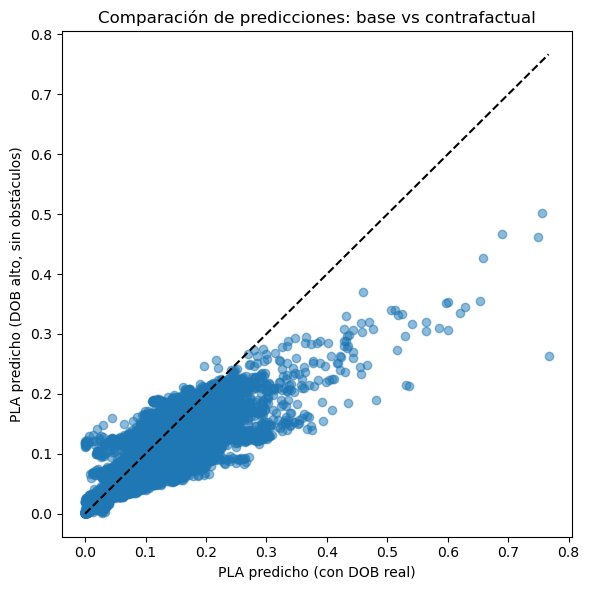

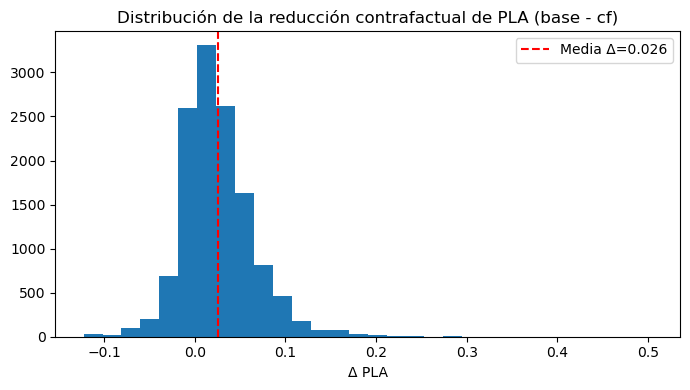

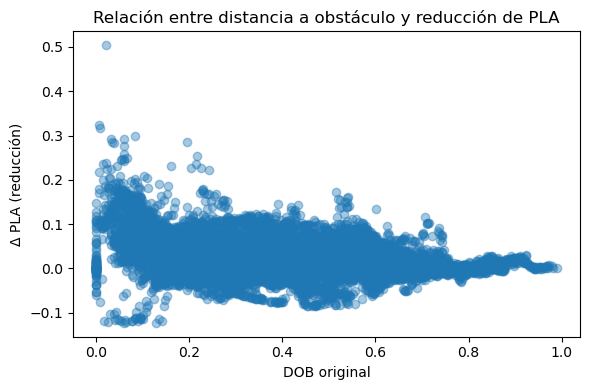

In [45]:
##################################################################
##################### EFECTO DE DOB ##############################
##################################################################

# --- 5) Escenario contrafactual: DOB alto (sin obstáculos cercanos) ---

pla_base = modelo_rf_grid.predict(X_test)
pla_cf   = modelo_rf_grid.predict(X_cf)

delta = pla_base - pla_cf  # >0 implica reducción de PLA al "alejar" el obstáculo

# --- 6) Estadísticos de efecto ---
summary = pd.Series({
    "n": len(delta),
    "Delta_mean": np.mean(delta),
    "Delta_median": np.median(delta),
    "p05": np.percentile(delta, 5),
    "p25": np.percentile(delta, 25),
    "p75": np.percentile(delta, 75),
    "p95": np.percentile(delta, 95)
})
print("\nReducción contrafactual de PLA (base - cf):\n", summary)

# --- 7) Gráficas comparativas ---
import seaborn as sns  # si lo usas en tu proyecto; si no, usa solo matplotlib

# Scatter base vs counterfactual
plt.figure(figsize=(6,6))
plt.scatter(pla_base, pla_cf, alpha=0.5)
lims = [min(pla_base.min(), pla_cf.min()), max(pla_base.max(), pla_cf.max())]
plt.plot(lims, lims, 'k--')
plt.xlabel("PLA predicho (con DOB real)")
plt.ylabel("PLA predicho (DOB alto, sin obstáculos)")
plt.title("Comparación de predicciones: base vs contrafactual")
plt.tight_layout()

# Guardar la figura en el directorio
plt.savefig(os.path.join(parent_directory, 'images','DOBH_scatter_base_vs_cf.png'), bbox_inches='tight', dpi=300)
plt.show()

# Histograma del delta
plt.figure(figsize=(7,4))
plt.hist(delta, bins=30)
plt.axvline(np.mean(delta), color='r', linestyle='--', label=f"Media Δ={np.mean(delta):.3f}")
plt.title("Distribución de la reducción contrafactual de PLA (base - cf)")
plt.xlabel("Δ PLA")
plt.legend()
plt.tight_layout()
# Guardar la figura en el directorio
plt.savefig(os.path.join(parent_directory, 'images','DOBH_histograma_delta.png'), bbox_inches='tight', dpi=300)
plt.show()

# Δ vs DOB original: ¿mayor reducción cuando el punto está más cerca del obstáculo?
plt.figure(figsize=(6,4))
plt.scatter(X_test["DOB"], delta, alpha=0.4)
plt.xlabel("DOB original")
plt.ylabel("Δ PLA (reducción)")
plt.title("Relación entre distancia a obstáculo y reducción de PLA")
plt.tight_layout()
# Guardar la figura en el directorio
plt.savefig(os.path.join(parent_directory, 'images','DOBH_delta_vs_dob.png'), bbox_inches='tight', dpi=300)
plt.show()

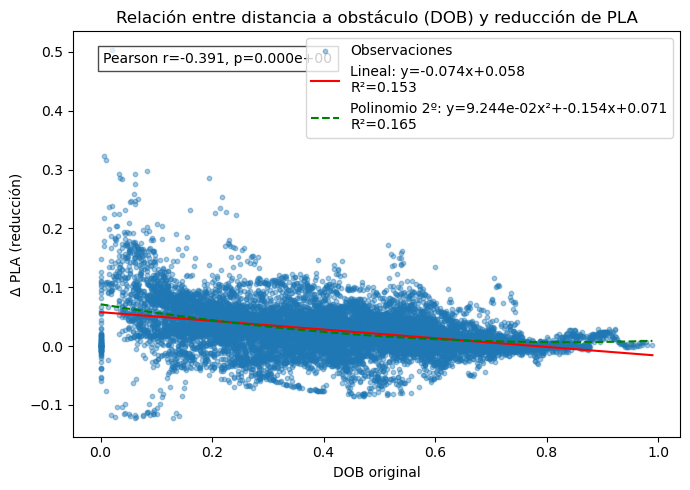

In [48]:
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
import numpy as np

# Scatter Δ vs DOB original con puntos pequeños
plt.figure(figsize=(7,5))
plt.scatter(X_test["DOB"], delta, alpha=0.4, s=10, label="Observaciones")  # s=10 puntos más pequeños

# --- 1) Regresión lineal ---
coef = np.polyfit(X_test["DOB"], delta, 1)  # ajuste lineal
poly1d_fn = np.poly1d(coef)
y_pred_lin = poly1d_fn(X_test["DOB"])
r2_lin = r2_score(delta, y_pred_lin)

# Correlación de Pearson
r, p = pearsonr(X_test["DOB"], delta)

# Dibujar recta de regresión
x_vals = np.linspace(X_test["DOB"].min(), X_test["DOB"].max(), 200)
plt.plot(x_vals, poly1d_fn(x_vals), 'r-', label=f"Lineal: y={coef[0]:.3f}x+{coef[1]:.3f}\nR²={r2_lin:.3f}")

# --- 2) Ajuste no lineal (polinomio de grado 2) ---
coef2 = np.polyfit(X_test["DOB"], delta, 2)
poly2d_fn = np.poly1d(coef2)
y_pred_quad = poly2d_fn(X_test["DOB"])
r2_quad = r2_score(delta, y_pred_quad)

plt.plot(x_vals, poly2d_fn(x_vals), 'g--', label=f"Polinomio 2º: y={coef2[0]:.3e}x²+{coef2[1]:.3f}x+{coef2[2]:.3f}\nR²={r2_quad:.3f}")

# Etiquetas y título
plt.xlabel("DOB original")
plt.ylabel("Δ PLA (reducción)")
plt.title("Relación entre distancia a obstáculo (DOB) y reducción de PLA")

# Leyenda con resultados
plt.legend()

# Mostrar coeficiente de Pearson en texto dentro del gráfico
plt.text(0.05, 0.95,
         f"Pearson r={r:.3f}, p={p:.3e}",
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig(os.path.join(parent_directory, 'images','DOBH_delta_vs_dob_regresion.png'), bbox_inches='tight', dpi=300)
plt.show()


In [ ]:
# --- 3. Support Vector Machine (SVR) ---

from sklearn.svm import SVR # Support Vector Regressor

# Definir la cuadrícula de hiperparámetros para SVR
grid_svr = {
    'kernel': ['rbf'],           # kernel RBF
    'C': [10],      # Parámetro de regularización
    'epsilon': [0.01], # Parámetro epsilon del tubo
    'gamma': ['scale']   # Coeficiente del kernel (para 'rbf')
}

# Si quisieras probar 'poly' kernel, añadirías 'degree' a la cuadrícula:
# grid_svr = {
#     'kernel': ['rbf', 'linear', 'poly'],
#     'C': [0.1, 1, 10],
#     'epsilon': [0.01, 0.1, 0.5],
#     'gamma': ['scale', 'auto'],
#     'degree': [2, 3] # Solo relevante para kernel='poly'
# }

# Inicializar el modelo base SVR
model_svr_base = SVR()

# Configurar GridSearchCV para la búsqueda de hiperparámetros y CV
modelo_svr_grid = GridSearchCV(
    estimator=model_svr_base,
    param_grid=grid_svr,
    cv=10, # 10-fold cross-validation
    scoring=scoring_metric,
    verbose=1, # Muestra el progreso
    n_jobs=n_cores, # Paralelización
    return_train_score=False
)

# Entrenar el modelo
print("\nIniciando entrenamiento del modelo SVR con GridSearchCV...")
modelo_svr_grid.fit(X_train, y_train)

# Mejores hiperparámetros
print("\nMejores hiperparámetros SVR:")
print(modelo_svr_grid.best_params_)

# Mejor score (RMSE negativo)
print(f"Mejor score de validación (neg_root_mean_squared_error): {modelo_svr_grid.best_score_:.4f}")
print(f"Mejor RMSE de validación: {-modelo_svr_grid.best_score_:.4f}")

# Guardar el mejor modelo entrenado
#model_svr_path = 'modelo_svr.pkl'
#joblib.dump(modelo_svr_grid.best_estimator_, model_svr_path)
#print(f"\nModelo SVR guardado como '{model_svr_path}'")

In [14]:
# --- 4. Realizar Predicciones y Evaluar ---
# Realizar predicciones sobre el conjunto de prueba (en la escala normalizada)
predicciones_svr_scaled = modelo_svr_grid.predict(X_test)
print(f"Predicciones SVR en escala normalizada (primeras 5): {predicciones_svr_scaled[:5]}")

Predicciones SVR en escala normalizada (primeras 5): [0.11639816 0.09697965 0.12016491 0.13115665 0.23574471]


In [15]:
# Desnormalizar manualmente las predicciones
predicciones_svr_desnormalized = predicciones_svr_scaled * range_pla + min_pla

# Desnormalizar los valores reales de prueba (data_test_labels) para comparación
y_test_desnormalized = y_test * range_pla + min_pla

print(f"Predicciones SVR desnormalizadas (primeras 5): {predicciones_svr_desnormalized[:5]}")
print(f"Valores reales desnormalizados (primeras 5): {y_test_desnormalized[:5]}")

# --- Calcular métricas con valores desnormalizados ---
rmse_desnormalized_svr = np.sqrt(mean_squared_error(y_test_desnormalized, predicciones_svr_desnormalized))
mae_desnormalized_svr = mean_absolute_error(y_test_desnormalized, predicciones_svr_desnormalized)
r2_desnormalized_svr = r2_score(y_test_desnormalized, predicciones_svr_desnormalized)

print(f"\n--- Métricas SVR en la ESCALA ORIGINAL (desnormalizada) ---")
print(f"RMSE: {rmse_desnormalized_svr:.4f}")
print(f"MAE: {mae_desnormalized_svr:.4f}")
print(f"R-squared: {r2_desnormalized_svr:.4f}")

Predicciones SVR desnormalizadas (primeras 5): [1.08026102 0.90004287 1.11521925 1.21723077 2.18788526]
Valores reales desnormalizados (primeras 5): 59999    1.609510
21880    1.044730
26228    1.112110
51256    0.998878
33816    2.237220
Name: PLA, dtype: float64

--- Métricas SVR en la ESCALA ORIGINAL (desnormalizada) ---
RMSE: 0.3021
MAE: 0.1852
R-squared: 0.7844


In [22]:
# Guardar los resultados en un diccionario y crear una tabla de resultados

# Crear un diccionario con los resultados
results_data = {
    'Métrica': ['RMSE', 'MAE', 'R-squared'],
    'Random Forest': [rmse_desnormalized_rf, mae_desnormalized_rf, r2_desnormalized_rf],
    'GBM (XGBoost)': [rmse_desnormalized_gbm, mae_desnormalized_gbm, r2_desnormalized_gbm],
    'SVM': [rmse_desnormalized_svr, mae_desnormalized_svr, r2_desnormalized_svr]
}

# Convertir el diccionario a un DataFrame de pandas
results_df = pd.DataFrame(results_data)

# Redondear los valores para una mejor presentación
results_df_rounded = results_df.round(4)

print("--- Comparación de Resultados de Modelos ---")
print(results_df_rounded.to_string(index=False)) # .to_string(index=False) para no mostrar el índice del DataFrame


--- Comparación de Resultados de Modelos ---
  Métrica  Random Forest  GBM (XGBoost)    SVM
     RMSE         0.1267         0.2446 0.3021
      MAE         0.0456         0.1570 0.1852
R-squared         0.9621         0.8587 0.7844


DataFrame de métricas para graficar:
          Modelo    RMSE     MAE  R-squared
0  Random Forest  0.1267  0.0456     0.9621
1  GBM (XGBoost)  0.2446  0.1570     0.8587
2            SVM  0.3021  0.1852     0.7844


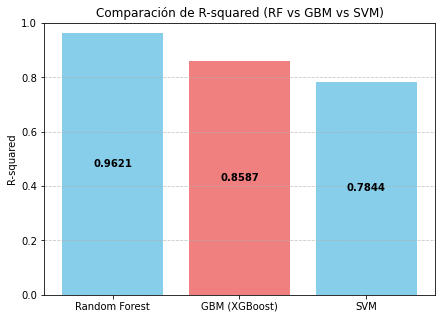

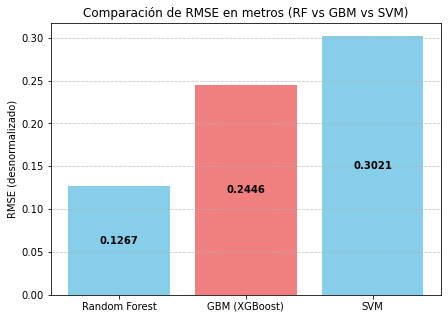

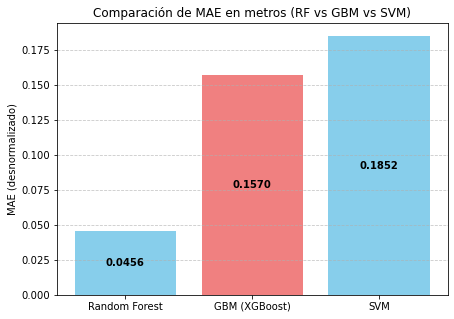

In [23]:
#  Visualización de un gráfico de barras
# Crear un DataFrame para la gráfica de RMSE

import matplotlib.pyplot as plt

# Crear un DataFrame para facilitar la graficación de comparaciones
metrics_df = pd.DataFrame({
    'Modelo': ['Random Forest', 'GBM (XGBoost)', 'SVM'],
    'RMSE': [rmse_desnormalized_rf, rmse_desnormalized_gbm, rmse_desnormalized_svr],
    'MAE': [mae_desnormalized_rf, mae_desnormalized_gbm, mae_desnormalized_svr],
    'R-squared': [r2_desnormalized_rf, r2_desnormalized_gbm, r2_desnormalized_svr]
})

print("DataFrame de métricas para graficar:")
print(metrics_df.round(4))


# --- Crear las tres gráficas separadas para comparación ---

# Gráfica 1: Comparación de R-squared
plt.figure(figsize=(7, 5))
bars = plt.bar(metrics_df['Modelo'], metrics_df['R-squared'], color=['skyblue', 'lightcoral'])
plt.title('Comparación de R-squared (RF vs GBM vs SVM)')
plt.ylabel('R-squared')
plt.ylim(0, 1) # R-squared typically ranges from 0 to 1
# Añadir valores DENTRO de las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval / 2, # Posición X en el centro de la barra, Y a la mitad de la altura
             f'{yval:.4f}', ha='center', va='center', color='black',
             fontsize=10, weight='bold') # Ajusta color y tamaño si es necesario
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Guardar la figura en el directorio
plt.savefig(os.path.join(parent_directory, 'images','R2_gbm_rf_svm.png'), bbox_inches='tight', dpi=300)
plt.show()

# Gráfica 2: Comparación de RMSE
plt.figure(figsize=(7, 5))
bars = plt.bar(metrics_df['Modelo'], metrics_df['RMSE'], color=['skyblue', 'lightcoral'])
plt.title('Comparación de RMSE en metros (RF vs GBM vs SVM)')
plt.ylabel('RMSE (desnormalizado)')
# Añadir valores DENTRO de las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval / 2, # Posición X en el centro de la barra, Y a la mitad de la altura
             f'{yval:.4f}', ha='center', va='center', color='black',
             fontsize=10, weight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Guardar la figura en el directorio
plt.savefig(os.path.join(parent_directory, 'images','RMSE_gbm_rf_svm.png'), bbox_inches='tight', dpi=300)

plt.show()

# Gráfica 3: Comparación de MAE
plt.figure(figsize=(7, 5))
bars = plt.bar(metrics_df['Modelo'], metrics_df['MAE'], color=['skyblue', 'lightcoral'])
plt.title('Comparación de MAE en metros (RF vs GBM vs SVM)')
plt.ylabel('MAE (desnormalizado)')
# Añadir valores DENTRO de las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval / 2, # Posición X en el centro de la barra, Y a la mitad de la altura
             f'{yval:.4f}', ha='center', va='center', color='black',
             fontsize=10, weight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Guardar la figura en el directorio
plt.savefig(os.path.join(parent_directory, 'images','MAE_gbm_rf_svm.png'), bbox_inches='tight', dpi=300)

plt.show()


DataFrame para el mapa (primeras 5 filas):
             POINT_X       POINT_Y  PLA_Real  PLA_Predicho
59999  723539.712912  4.368119e+06  1.609510      1.212310
21880  723069.078224  4.366624e+06  1.044730      1.054757
26228  723022.390076  4.366947e+06  1.112110      1.001113
51256  722727.906662  4.367564e+06  0.998878      0.915229
33816  722147.814710  4.367393e+06  2.237220      1.795897

DataFrame combinado guardado exitosamente como 'mapa_PLA_real_predicho.csv' en 'C:\Users\cuent\En-Peu\data\mapa_PLA_real_predicho.csv'


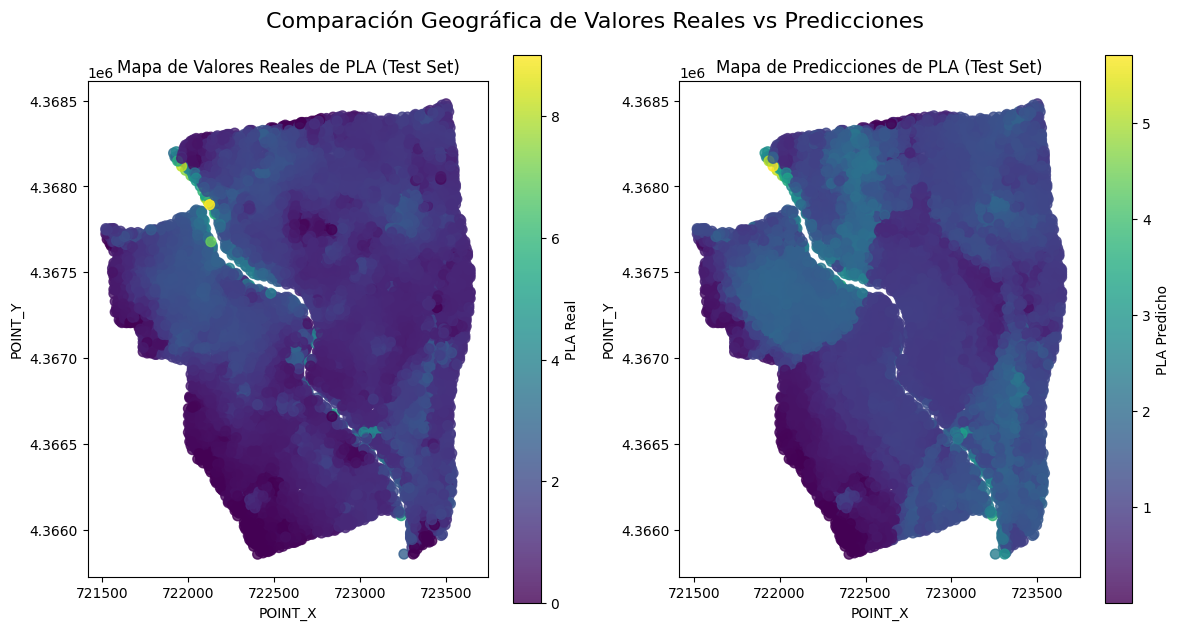

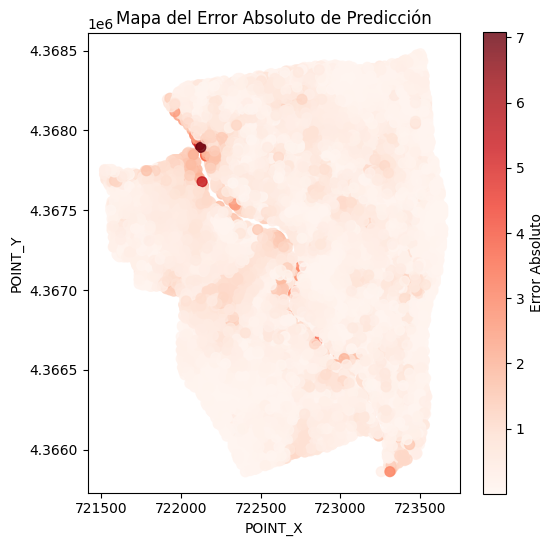

In [80]:
# --- COMBINAR COORDENADAS Y PREDICCIONES PARA EL MAPA ---
# Crear un DataFrame con los valores reales, predicciones y coordenadas para el conjunto de prueba
map_data = pd.DataFrame({
    'POINT_X': coordinates_test['POINT_X'],
    'POINT_Y': coordinates_test['POINT_Y'],
    'PLA_Real': y_test_desnormalized,
    'PLA_Predicho': predicciones_rf_desnormalized
})

print("\nDataFrame para el mapa (primeras 5 filas):")
print(map_data.head())

# Guardar el resultado en un nuevo CSV
nombre_archivo_salida = "mapa_PLA_real_predicho.csv"
map_data.to_csv(os.path.join(parent_directory,'data',nombre_archivo_salida), index=False) # index=False evita guardar el índice de pandas como una columna

print(f"\nDataFrame combinado guardado exitosamente como '{nombre_archivo_salida}' en '{os.path.join(parent_directory,'data',nombre_archivo_salida)}'")

# --- HACER EL MAPA DE LAS PREDICCIONES ---


plt.figure(figsize=(12, 6))

# Gráfico de dispersión para los valores reales
ax1 = plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
scatter1 = ax1.scatter(map_data['POINT_X'], map_data['POINT_Y'],
                       c=map_data['PLA_Real'], cmap='viridis', s=50, alpha=0.8)
ax1.set_title('Mapa de Valores Reales de PLA (Test Set)')
ax1.set_xlabel('POINT_X')
ax1.set_ylabel('POINT_Y')
plt.colorbar(scatter1, ax=ax1, label='PLA Real')
ax1.set_aspect('equal', adjustable='box') # CORRECTED: Called on ax1

# Gráfico de dispersión para las predicciones
ax2 = plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
scatter2 = ax2.scatter(map_data['POINT_X'], map_data['POINT_Y'],
                       c=map_data['PLA_Predicho'], cmap='viridis', s=50, alpha=0.8)
ax2.set_title('Mapa de Predicciones de PLA (Test Set)')
ax2.set_xlabel('POINT_X')
ax2.set_ylabel('POINT_Y')
plt.colorbar(scatter2, ax=ax2, label='PLA Predicho')
ax2.set_aspect('equal', adjustable='box') # CORRECTED: Called on ax2

plt.tight_layout()
plt.suptitle('Comparación Geográfica de Valores Reales vs Predicciones', y=1.05, fontsize=16)

# Guardar la figura en el directorio
plt.savefig(os.path.join(parent_directory, 'images','mapa_predicciones_PLA.png'), bbox_inches='tight', dpi=300)

plt.show()

# Opcional: Para visualizar las diferencias (errores)
plt.figure(figsize=(6, 6))
# Calcular el error absoluto para colorear
map_data['Error_Absoluto'] = np.abs(map_data['PLA_Real'] - map_data['PLA_Predicho'])
ax_error = plt.gca() # Get the current Axes object for this single subplot
scatter_error = ax_error.scatter(map_data['POINT_X'], map_data['POINT_Y'], # CORRECTED: Use ax_error for scatter
                            c=map_data['Error_Absoluto'], cmap='Reds', s=50, alpha=0.8)
ax_error.set_title('Mapa del Error Absoluto de Predicción') # CORRECTED: Set title on ax_error
ax_error.set_xlabel('POINT_X') # CORRECTED: Set xlabel on ax_error
ax_error.set_ylabel('POINT_Y') # CORRECTED: Set ylabel on ax_error
plt.colorbar(scatter_error, ax=ax_error, label='Error Absoluto') # CORRECTED: Pass ax=ax_error to colorbar
ax_error.set_aspect('equal', adjustable='box') # CORRECTED: Called on ax_error

# Guardar la figura en el directorio
plt.savefig(os.path.join(parent_directory, 'images','mapa_error_absoluto.png'), bbox_inches='tight', dpi=300)


plt.show()


DataFrame combinado guardado exitosamente como 'DOBH_PLAbase_PLAcf_delta.csv' en 'C:\Users\cuent\En-Peu\data\DOBH_PLAbase_PLAcf_delta.csv'


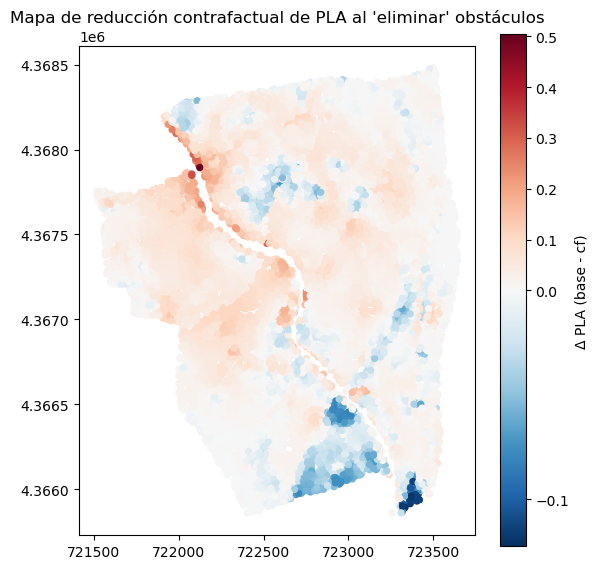

In [47]:
map_df = pd.DataFrame({
    "POINT_X": coordinates_test["POINT_X"],  # el dataframe que uses
    "POINT_Y": coordinates_test["POINT_Y"],
    "PLA_base": pla_base,
    "PLA_cf": pla_cf,
    "Delta": delta
})

# Guardar el resultado en un nuevo CSV
nombre_archivo_salida = "DOBH_PLAbase_PLAcf_delta.csv"
map_df.to_csv(os.path.join(parent_directory,'data',nombre_archivo_salida), index=False) # index=False evita guardar el índice de pandas como una columna

print(f"\nDataFrame combinado guardado exitosamente como '{nombre_archivo_salida}' en '{os.path.join(parent_directory,'data',nombre_archivo_salida)}'")



# Mapa de Δ (reducción)
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Normalización: fuerza que el centro esté en 0
norm = TwoSlopeNorm(vcenter=0, vmin=map_df.Delta.min(), vmax=map_df.Delta.max())

plt.figure(figsize=(6,6))
sc = plt.scatter(
    map_df.POINT_X,
    map_df.POINT_Y,
    c=map_df.Delta,
    cmap="RdBu_r",
    norm=norm,          # 👈 le decimos cómo normalizar
    s=18
)
plt.colorbar(sc, label="Δ PLA (base - cf)")
plt.title("Mapa de reducción contrafactual de PLA al 'eliminar' obstáculos")
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()

plt.savefig(os.path.join(parent_directory, 'images','mapa_variacion_PLA_segun_DOB.png'),
            bbox_inches='tight', dpi=300)
plt.show()

In [119]:
import pandas as pd
import numpy as np
import joblib
import os

# --- Cargar datos normalizados (ya tienen pla_base, pla_cf y delta normalizado) ---
nombre_archivo = "DOBH_PLAbase_PLAcf_delta.csv"
data_sin_DOB = pd.read_csv(os.path.join(parent_directory, 'data', nombre_archivo)) 

print("\nResumen datos normalizados:")
print(data_sin_DOB.describe())

# --- Cargar scaler entrenado ---
scaler_path = os.path.join(parent_directory, 'data','min_max_scaler.pkl')
loaded_scaler = joblib.load(scaler_path)

# --- Identificar índice de PLA en el scaler ---
# scaler.feature_names_in_ contiene los nombres de columnas usadas en el fit
pla_idx = list(loaded_scaler.feature_names_in_).index("PLA")
print("\nIndice pla:")
print(pla_idx)


min_pla = loaded_scaler.data_min_[pla_idx]
range_pla = loaded_scaler.data_range_[pla_idx]

print(f"\nScaler cargado. PLA -> min: {min_pla:.4f}, range: {range_pla:.4f}")

# --- Desnormalizar las predicciones ---
data_sin_DOB["PLA_base_desnorm"] = data_sin_DOB["PLA_base"] * range_pla + min_pla
data_sin_DOB["PLA_cf_desnorm"]   = data_sin_DOB["PLA_cf"]   * range_pla + min_pla

# --- Calcular delta en escala original ---
data_sin_DOB["delta_desnorm"] = data_sin_DOB["PLA_base_desnorm"] - data_sin_DOB["PLA_cf_desnorm"]

print("\nResumen datos desnormalizados:")
print(data_sin_DOB[["PLA_base_desnorm","PLA_cf_desnorm","delta_desnorm"]].describe())

# --- Guardar resultado en nuevo CSV ---
out_file = os.path.join(parent_directory, 'data',"DOBH_PLAbase_PLAcf_delta_desnorm.csv")
data_sin_DOB.to_csv(out_file, index=False)
print(f"\nArchivo guardado en: {out_file}")



Resumen datos normalizados:
             POINT_X       POINT_Y      PLA_base        PLA_cf         Delta
count   12869.000000  1.286900e+04  12869.000000  12869.000000  12869.000000
mean   722733.230839  4.367234e+06      0.143931      0.118165      0.025766
std       511.851178  6.623626e+02      0.067744      0.049487      0.039686
min    721520.945013  4.365860e+06      0.000000      0.000461     -0.122611
25%    722334.253247  4.366685e+06      0.101880      0.085154      0.000915
50%    722758.649636  4.367271e+06      0.138681      0.118993      0.020813
75%    723170.002295  4.367763e+06      0.185498      0.155086      0.045339
max    723640.976318  4.368481e+06      0.766758      0.502399      0.503796

Indice pla:
0

Scaler cargado. PLA -> min: 0.0000, range: 9.2807

Resumen datos desnormalizados:
       PLA_base_desnorm  PLA_cf_desnorm  delta_desnorm
count      12869.000000    12869.000000   12869.000000
mean           1.335785        1.096654       0.239131
std            

In [115]:
map_df = pd.DataFrame({
    "POINT_X": coordinates_test["POINT_X"],  # el dataframe que uses
    "POINT_Y": coordinates_test["POINT_Y"],
    "PLA_base": pla_base,
    "PLA_cf": pla_cf,
    "Delta": delta
})
# Guardar el resultado en un nuevo CSV
nombre_archivo_salida = "mapa_PLA_DOB_max.csv"
map_data.to_csv(os.path.join(parent_directory,'data',nombre_archivo_salida), index=False) # index=False evita guardar el índice de pandas como una columna

print(f"\nDataFrame combinado guardado exitosamente como '{nombre_archivo_salida}' en '{os.path.join(parent_directory,'data',nombre_archivo_salida)}'")


NameError: name 'pla_base' is not defined

Vamos a añadir un gradiente de altitud al río, para ver los puntos con mayor altitud y los puntos con menor altitud y ver así cómo fluye el agua. Para ello hay que rescatar los puntos en los que la variable B (Barranco) es igual a 1, que fueron excluídos del modelo.

In [87]:
file_path_2 = os.path.join(parent_directory, 'data', 'datos_combinados.csv')

# Cargar datos originales

data_original = pd.read_csv(file_path_2)

# --- PASO 1: Filtrar datos donde B = 1 (puntos del río) ---
# Usamos el DataFrame original antes de cualquier filtrado o eliminación de 'B'
barranco = data_original[data_original['B'] == 1].copy() # .copy() para evitar SettingWithCopyWarning

print("\nDatos del barranco (B=1) - Primeras 5 filas:")
print(barranco.head())
print(f"Número de puntos en el río: {len(barranco)}")

count_neg_9999 = barranco[barranco['A'] == -9999].shape[0]

# Conteo de 0
count_zero = barranco[barranco['A'] == 0].shape[0]

print(f"\nConteo de valores de 'Altitud' en puntos donde B = 1:")
print(f"  Valores = -9999: {count_neg_9999} filas")
print(f"  Valores = 0: {count_zero} filas")


Datos del barranco (B=1) - Primeras 5 filas:
            POINT_X       POINT_Y     PLA  grid_cod       A    AC  B  \
9038  722682.054059  4.366839e+06 -9999.0     50209  13.818 -9999  1   
9126  722682.048060  4.366847e+06 -9999.0     50547   0.000 -9999  1   
9213  722674.305199  4.366855e+06 -9999.0     50884   0.000 -9999  1   
9214  722682.042141  4.366855e+06 -9999.0     50885   0.000 -9999  1   
9301  722674.299207  4.366862e+06 -9999.0     51222   0.000 -9999  1   

           CIB   CICCB   CUS       DBB     DOB    OC           P  
9038  0.199083 -9999.0 -9999   2.82843 -9999.0 -9999     7.94657  
9126  0.199725 -9999.0 -9999   7.21110 -9999.0 -9999 -9999.00000  
9213  0.200739 -9999.0 -9999   4.47214 -9999.0 -9999 -9999.00000  
9214  0.199855 -9999.0 -9999  11.66190 -9999.0 -9999 -9999.00000  
9301  0.200739 -9999.0 -9999   8.24621 -9999.0 -9999 -9999.00000  
Número de puntos en el río: 2352

Conteo de valores de 'Altitud' en puntos donde B = 1:
  Valores = -9999: 0 filas
  Va

In [ ]:
Al parecer hay muchos valores con Altitud=0, por lo tanto esto no nos ayuda a ver el gradiente. 
Habría que calcularlo según los puntos de alrededor. Se pueden imputar usando KDTree de scipy.

In [89]:
from scipy.spatial import KDTree 

# --- Filtros de datos: puntos fuera del río y puntos del río ---
# Puntos fuera del río (B=0) y que tienen valores de Altitud válidos
# Se excluyen Altitud = 0 o -9999 de los puntos que usaremos para imputar
land_data = data_original[(data_original['B'] == 0) &
                          (data_original['A'] != 0)].copy()

# Puntos del río (B=1) - Estos son los que queremos imputar si tienen problemas
river_data_original = data_original[data_original['B'] == 1].copy()

print(f"\nNúmero de puntos terrestres válidos para imputar (B=0, Altitud != 0, -9999): {len(land_data)}")
print(f"Número de puntos del río (B=1): {len(river_data_original)}")


Número de puntos terrestres válidos para imputar (B=0, Altitud != 0, -9999): 64632
Número de puntos del río (B=1): 2352


In [106]:
# --- Preparar datos para KDTree (solo puntos terrestres válidos) ---
if land_data.empty or 'A' not in land_data.columns:
    print("ERROR: No hay datos terrestres válidos con Altitud para realizar la imputación.")
    # Si no hay datos terrestres válidos, no podemos imputar.
    # Podrías optar por salir o manejar esta situación de otra manera.
    river_data_imputed = river_data_original.copy() # Si no se puede imputar, usa los originales
    river_data_imputed['Altitud_Imputada'] = river_data_imputed['A'] # Mantén la columna
else:
    # Coordenadas de los puntos terrestres con altitud válida
    land_coords = land_data[['POINT_X', 'POINT_Y']].values
    land_altitudes = land_data['A'].values
    land_tree = KDTree(land_coords)

    # DataFrame para almacenar los puntos del río con altitud imputada
    river_data_imputed = river_data_original.copy()
    river_data_imputed['Altitud_Imputada'] = np.nan # Columna para la altitud imputada

    # Identificar puntos del río con altitud faltante o errónea
    points_to_impute_mask = (river_data_imputed['A'] == 0) | \
                            (river_data_imputed['A'] == -9999) | \
                            river_data_imputed['A'].isnull()

    points_to_impute = river_data_imputed[points_to_impute_mask]
    points_valid_river = river_data_imputed[~points_to_impute_mask]

    print(f"\nNúmero de puntos del río con Altitud faltante/errónea a imputar: {len(points_to_impute)}")
    print(f"Número de puntos del río con Altitud válida (no se imputarán): {len(points_valid_river)}")

    # --- Imputar la altitud para los puntos del río con problemas ---
    if not points_to_impute.empty:
        imputed_altitudes = []
        # Parámetros para la búsqueda de vecinos cercanos y IDW
        k_neighbors = 5 # Número de vecinos más cercanos a considerar
        power = 2     # Potencia para IDW (mayor potencia = mayor peso a los vecinos más cercanos)

        for idx, row in points_to_impute.iterrows():
            query_point = [row['POINT_X'], row['POINT_Y']]
            distances, indices = land_tree.query(query_point, k=k_neighbors)

            # Evitar división por cero si la distancia es 0 (punto exacto)
            if 0.0 in distances:
                # Si hay un punto exacto, usar su altitud directamente
                closest_altitude = land_altitudes[indices[np.argmin(distances)]]
                imputed_altitudes.append(closest_altitude)
            else:
                weights = 1 / (distances ** power)
                imputed_val = np.sum(weights * land_altitudes[indices]) / np.sum(weights)
                imputed_altitudes.append(imputed_val)

        # Asignar altitudes imputadas
        river_data_imputed.loc[points_to_impute_mask, 'Altitud_Imputada'] = imputed_altitudes
    
    # Para los puntos del río que ya tenían altitud válida, simplemente copiamos su valor
    river_data_imputed.loc[~points_to_impute_mask, 'Altitud_Imputada'] = river_data_imputed.loc[~points_to_impute_mask, 'A']

    print("\nPrimeras filas del DataFrame de río con Altitud_Imputada:")
    print(river_data_imputed.head())

# --- Normalizar la Altitud Imputada para el Color (para todos los puntos del río) ---
if not river_data_imputed.empty and 'Altitud_Imputada' in river_data_imputed.columns:
    min_altitud_imputed = river_data_imputed['Altitud_Imputada'].min()
    max_altitud_imputed = river_data_imputed['Altitud_Imputada'].max()

    if min_altitud_imputed == max_altitud_imputed:
        print("ADVERTENCIA: La Altitud_Imputada en los puntos del río es constante. No se aplicará gradiente.")
        river_data_imputed['Altitud_Normalized'] = 0.5
    else:
        river_data_imputed['Altitud_Normalized'] = \
            (river_data_imputed['Altitud_Imputada'] - min_altitud_imputed) / \
            (max_altitud_imputed - min_altitud_imputed)

    river_cmap = 'Reds'
    # Configurar ticks y etiquetas para la colorbar del río
    cbar_river_ticks_norm = np.linspace(0, 1, 5) # Ticks en el rango normalizado
    cbar_river_labels_real = np.round(cbar_river_ticks_norm * (max_altitud_imputed - min_altitud_imputed) + min_altitud_imputed, 1)

else:
    print("ADVERTENCIA: No hay datos de río con 'Altitud_Imputada' para graficar el gradiente.")
    river_data_imputed = pd.DataFrame() # Asegurarse de que esté vacío si no se puede procesar
    river_cmap = None


# --- COMBINAR COORDENADAS Y PREDICCIONES PARA EL MAPA (Tu código existente) ---
map_data = pd.DataFrame({
    'POINT_X': coordinates_test['POINT_X'],
    'POINT_Y': coordinates_test['POINT_Y'],
    'PLA_Real': y_test_desnormalized,
    'PLA_Predicho': predicciones_rf_desnormalized
})



Número de puntos del río con Altitud faltante/errónea a imputar: 2199
Número de puntos del río con Altitud válida (no se imputarán): 153

Primeras filas del DataFrame de río con Altitud_Imputada:
            POINT_X       POINT_Y     PLA  grid_cod       A    AC  B  \
9038  722682.054059  4.366839e+06 -9999.0     50209  13.818 -9999  1   
9126  722682.048060  4.366847e+06 -9999.0     50547   0.000 -9999  1   
9213  722674.305199  4.366855e+06 -9999.0     50884   0.000 -9999  1   
9214  722682.042141  4.366855e+06 -9999.0     50885   0.000 -9999  1   
9301  722674.299207  4.366862e+06 -9999.0     51222   0.000 -9999  1   

           CIB   CICCB   CUS       DBB     DOB    OC           P  \
9038  0.199083 -9999.0 -9999   2.82843 -9999.0 -9999     7.94657   
9126  0.199725 -9999.0 -9999   7.21110 -9999.0 -9999 -9999.00000   
9213  0.200739 -9999.0 -9999   4.47214 -9999.0 -9999 -9999.00000   
9214  0.199855 -9999.0 -9999  11.66190 -9999.0 -9999 -9999.00000   
9301  0.200739 -9999.0 -9999  

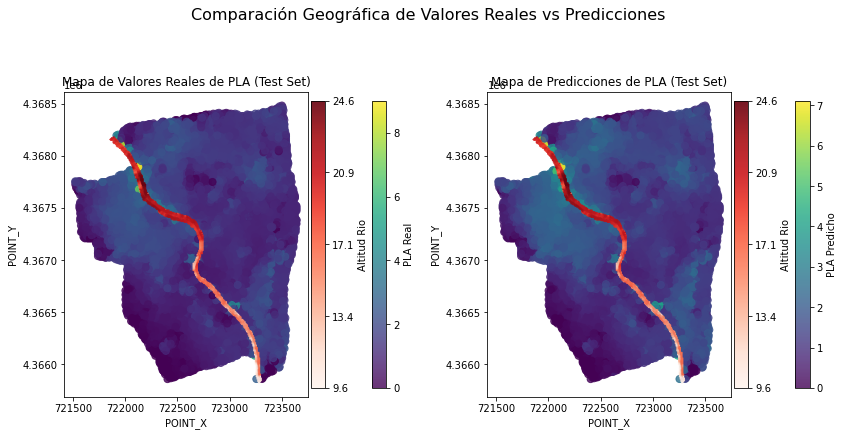

In [108]:
# --- HACER EL MAPA DE LAS PREDICCIONES ---


plt.figure(figsize=(12, 6))

# Gráfico de dispersión para los valores reales
ax1 = plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
scatter1 = ax1.scatter(map_data['POINT_X'], map_data['POINT_Y'],
                       c=map_data['PLA_Real'], cmap='viridis', s=50, alpha=0.8)
ax1.set_title('Mapa de Valores Reales de PLA (Test Set)')
ax1.set_xlabel('POINT_X')
ax1.set_ylabel('POINT_Y')
plt.colorbar(scatter1, ax=ax1, shrink=0.7, aspect=20, label='PLA Real')
ax1.set_aspect('equal', adjustable='box') # CORRECTED: Called on ax1

# Superponer los puntos del río si existen y tienen altitud imputada
if not river_data_imputed.empty and 'Altitud_Imputada' in river_data_imputed.columns:
    scatter_river_alt = ax1.scatter(river_data_imputed['POINT_X'], river_data_imputed['POINT_Y'],
                                    c=river_data_imputed['Altitud_Normalized'], cmap=river_cmap,
                                    s=2, alpha=0.9, edgecolor='none', linewidth=0.5, label='Río (Altitud)')
    cbar_river = plt.colorbar(scatter_river_alt, ax=ax1, label='Altitud Rio', shrink=0.7, aspect=20, pad=0.01) # Ajustado shrink, aspect, pad

    if min_altitud_imputed != max_altitud_imputed:
        cbar_river.set_ticks(cbar_river_ticks_norm)
        cbar_river.set_ticklabels(cbar_river_labels_real)


# Gráfico de dispersión para las predicciones
ax2 = plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
scatter2 = ax2.scatter(map_data['POINT_X'], map_data['POINT_Y'],
                       c=map_data['PLA_Predicho'], cmap='viridis', s=50, alpha=0.8)
ax2.set_title('Mapa de Predicciones de PLA (Test Set)')
ax2.set_xlabel('POINT_X')
ax2.set_ylabel('POINT_Y')
plt.colorbar(scatter2, ax=ax2, shrink=0.7, aspect=20, label='PLA Predicho')
ax2.set_aspect('equal', adjustable='box') # CORRECTED: Called on ax2


# Superponer los puntos del río si existen y tienen altitud imputada
if not river_data_imputed.empty and 'Altitud_Imputada' in river_data_imputed.columns:
    scatter_river_alt = ax2.scatter(river_data_imputed['POINT_X'], river_data_imputed['POINT_Y'],
                                    c=river_data_imputed['Altitud_Normalized'], cmap=river_cmap,
                                    s=2, alpha=0.9, edgecolor='none', linewidth=0.5, label='Río (Altitud)')
    cbar_river = plt.colorbar(scatter_river_alt, ax=ax2, label='Altitud Rio', shrink=0.7, aspect=20, pad=0.01) # Ajustado shrink, aspect, pad

    if min_altitud_imputed != max_altitud_imputed:
        cbar_river.set_ticks(cbar_river_ticks_norm)
        cbar_river.set_ticklabels(cbar_river_labels_real)


plt.tight_layout()
plt.suptitle('Comparación Geográfica de Valores Reales vs Predicciones', y=1.05, fontsize=16)

# Guardar la figura en el directorio
plt.savefig(os.path.join(parent_directory, 'images','mapa_predicciones_PLA_rio.png'), bbox_inches='tight', dpi=300)

plt.show()

In [ ]:
Y ahora vemos un gráfico de dispersión entre valores predichos y observados

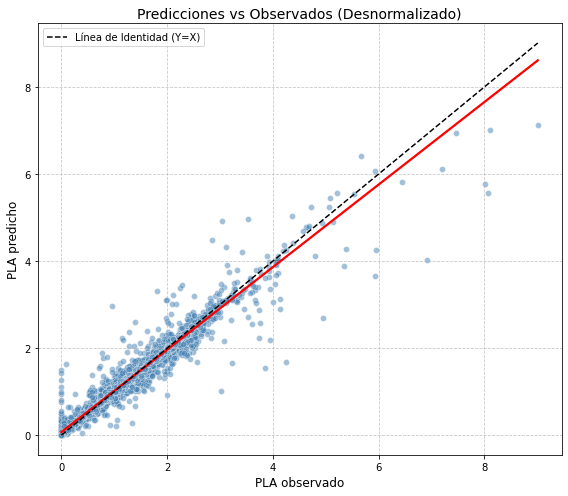

In [26]:
import seaborn as sns

# observado = y_test_desnormalized
# predicho = predicciones_rf_desnormalized

# Crear un DataFrame para ggplot/seaborn
plot_df = pd.DataFrame({
    'Observado': y_test_desnormalized,
    'Predicho': predicciones_rf_desnormalized
})

# --- Graficar ---
plt.figure(figsize=(8, 7))

# 1. Gráfico de dispersión
sns.scatterplot(data=plot_df, x='Observado', y='Predicho', alpha=0.5, color="steelblue")

# 2. Línea de regresión (geom_smooth(method = "lm", se = FALSE) en R)
# 'regplot' de seaborn es el equivalente más directo a geom_smooth(method="lm")
sns.regplot(data=plot_df, x='Observado', y='Predicho', scatter=False, color="red", line_kws={'linestyle':'solid'}, ci=None)

# 3. Línea de identidad (geom_abline(slope = 1, intercept = 0) en R)
plt.plot([plot_df['Observado'].min(), plot_df['Observado'].max()],
         [plot_df['Observado'].min(), plot_df['Observado'].max()],
         linestyle='dashed', color='black', label='Línea de Identidad (Y=X)')

# 4. Etiquetas y título
plt.title("Predicciones vs Observados (Desnormalizado)", fontsize=14)
plt.xlabel("PLA observado", fontsize=12)
plt.ylabel("PLA predicho", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7) # Añadir una cuadrícula
plt.legend() # Mostrar la leyenda para la línea de identidad
plt.tight_layout() # Ajustar el diseño

# Guardar la figura en el directorio
plt.savefig(os.path.join(parent_directory, 'images','dispersion_observado_predicho.png'), bbox_inches='tight', dpi=300)

plt.show()

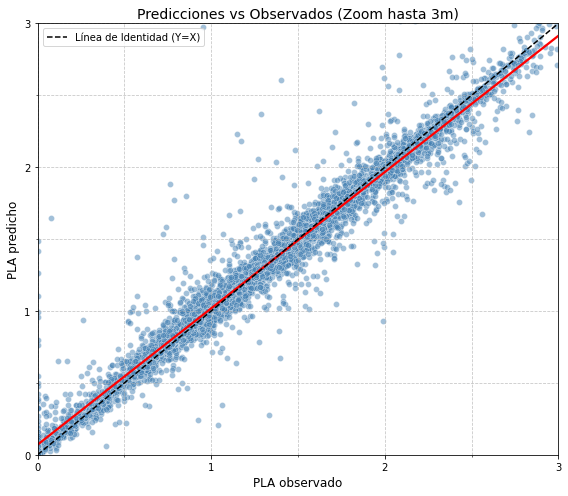

In [27]:
# --- Graficar con Zoom ---
plt.figure(figsize=(8, 7))

# 1. Gráfico de dispersión
sns.scatterplot(data=plot_df, x='Observado', y='Predicho', alpha=0.5, color="steelblue")

# 2. Línea de regresión
sns.regplot(data=plot_df, x='Observado', y='Predicho', scatter=False, color="red", line_kws={'linestyle':'solid'}, ci=None)

# 3. Línea de identidad
# Es importante que la línea de identidad también se extienda solo dentro del rango del zoom
min_val_zoom = 0
max_val_zoom = 3
plt.plot([min_val_zoom, max_val_zoom],
         [min_val_zoom, max_val_zoom],
         linestyle='dashed', color='black', label='Línea de Identidad (Y=X)')



# --- Configurar el Zoom y los Tickmarks ---
# Rango de valores hasta 3m
plt.xlim(min_val_zoom, max_val_zoom)
plt.ylim(min_val_zoom, max_val_zoom)

# Tickmarks cada 1m (major ticks)
major_ticks = np.arange(0, 3.1, 1) # Desde 0 hasta 3, con paso de 1
plt.xticks(major_ticks)
plt.yticks(major_ticks)

# Tickmarks sin número intermedias (minor ticks)
# Por ejemplo, cada 0.5m. Matplotlib las dibujará entre los major ticks
minor_ticks = np.arange(0, 3.1, 0.5) # Desde 0 hasta 3, con paso de 0.5
plt.gca().set_xticks(minor_ticks, minor=True) # Establecer minor ticks para el eje x
plt.gca().set_yticks(minor_ticks, minor=True) # Establecer minor ticks para el eje y

# Asegurarse de que los minor ticks se vean en la cuadrícula
plt.grid(True, which='both', linestyle='--', alpha=0.7) # 'both' para major y minor grids


# 4. Etiquetas y título
plt.title("Predicciones vs Observados (Zoom hasta 3m)", fontsize=14)
plt.xlabel("PLA observado", fontsize=12)
plt.ylabel("PLA predicho", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

Ahora podemos hacer unos Partial Dependence Plots, que nos dirán cómo afecta cada variable a PLA.

In [20]:
from sklearn.inspection import PartialDependenceDisplay # PDPs


# --- Seleccionar las características para los PDPs ---
# Se puede elegir las características más importantes del modelo.
# Para ello, usar la importancia de variables calculada para RF
features_to_plot = X_train.columns.tolist() # Estas serían todas las variables

# Para importancia de variables: feature_importances_rf 
#feature_importances_rf = pd.Series(modelo_rf_grid.best_estimator_.feature_importances_, index=X_train.columns)
#top_features = feature_importances_rf.nlargest(7).index.tolist() # Get top 5
#features_to_plot = top_features

print(f"\nGenerando PDPs para las características: {features_to_plot}")



Generando PDPs para las características: ['A', 'AC', 'CIB', 'CICCB', 'DBB', 'P', 'CUS_1', 'CUS_2', 'CUS_3', 'CUS_4', 'CUS_5', 'OC_1', 'OC_2', 'OC_3', 'OC_4']


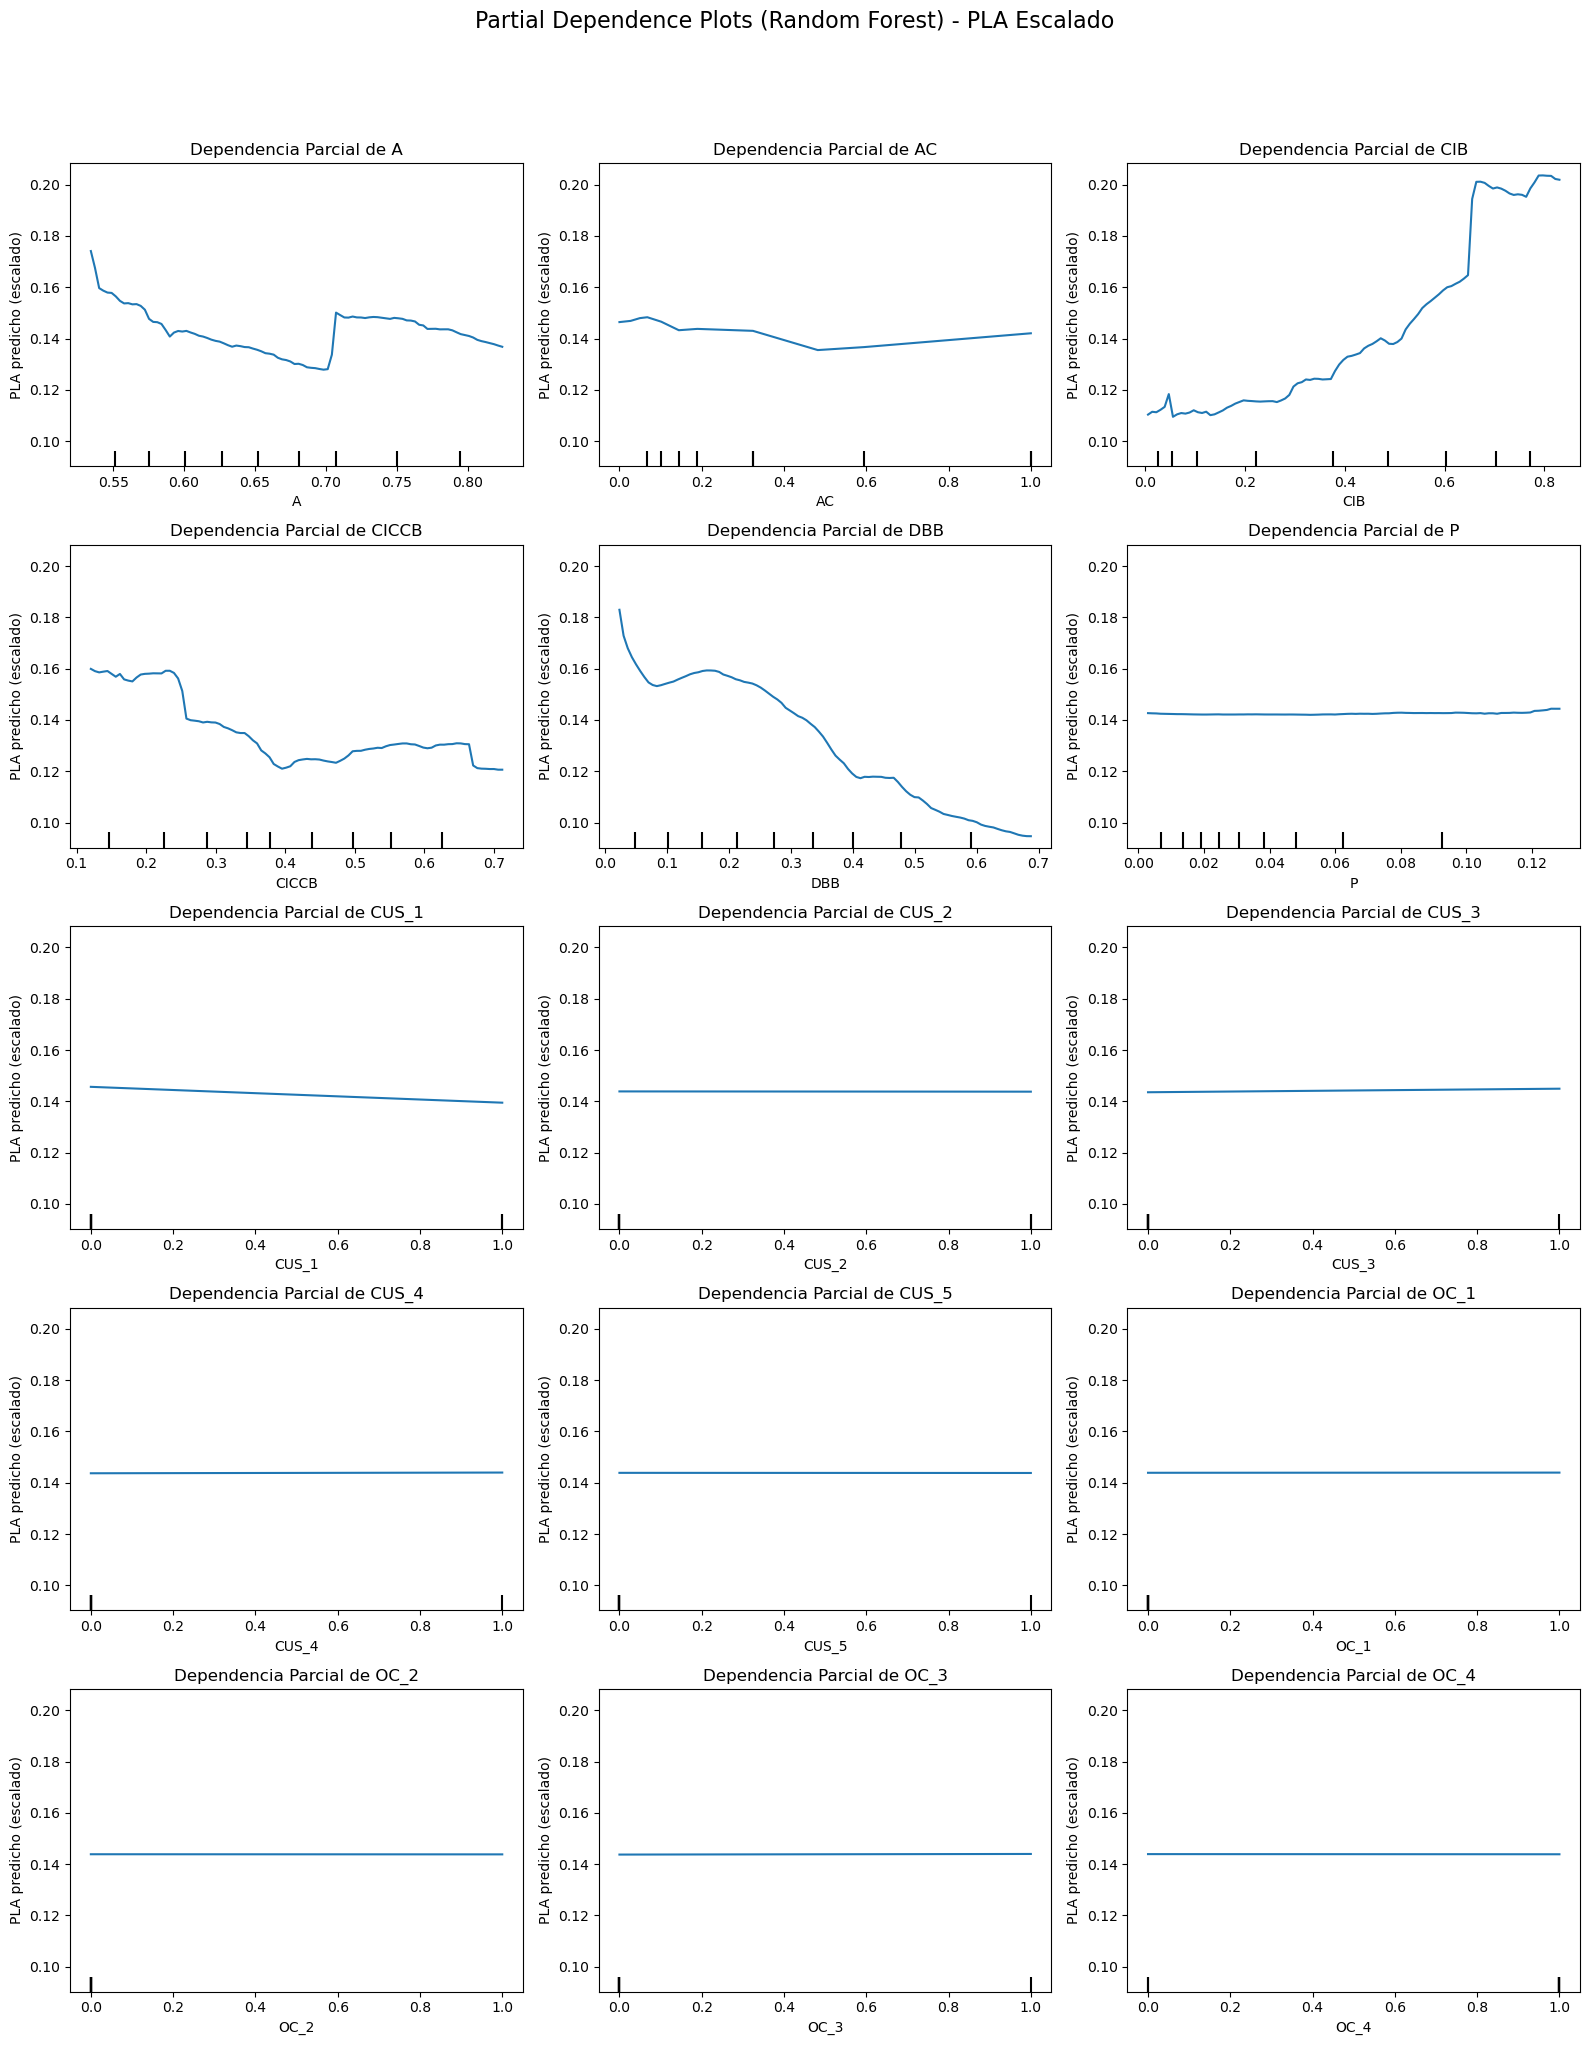

In [21]:
# --- Crear los Partial Dependence Plots ---
# Especificar el número de características en un grid (e.g., (1, 2) para 1-way PDPs)
# tambien se podrian hacer uno por uno para más control sobre cada gráfico.
import matplotlib.pyplot as plt
# --- Opción para controlar la desnormalización ---
# Cambiar esta variable a True para desnormalizar, o False para ver los valores escalados
DESNORMALIZAR_PDPS = False # <-- De momento True no funciona


# --- Ajustes para layout dinámico ---
n_features = len(features_to_plot)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

# --- Crear figura y ejes con el número exacto de subgráficas ---
fig, axs = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axs = axs.flatten()

# --- CREACIÓN DE PDPs ---
display = PartialDependenceDisplay.from_estimator(
    estimator=modelo_rf_grid.best_estimator_,
    X=X_train,
    features=features_to_plot,
    kind='average',
    n_jobs=-1,
    ax=axs[:n_features],  # Solo pasar tantos ejes como features
)

# --- Bucle para desnormalizar (si DESNORMALIZAR_PDPS es True) y etiquetar ---
for i in range(len(features_to_plot)):
    # Usar 'axs[i]' en lugar de 'all_axes_pdp[i]'
    current_ax = axs[i]

    if current_ax is None:
        print(f"WARNING: Axis at index {i} is None for One-Way PDP. Skipping desnormalization for this plot.")
        continue

    feature_name = features_to_plot[i]

    # Obtener los límites actuales del eje Y (escalados)
    ymin_scaled, ymax_scaled = current_ax.get_ylim()

    if DESNORMALIZAR_PDPS:
        # Desnormalizar los límites
        ymin_desnormalized = ymin_scaled * range_pla + min_pla
        ymax_desnormalized = ymax_scaled * range_pla + min_pla
        current_ax.set_ylim(ymin_desnormalized, ymax_desnormalized)
        current_ax.set_ylabel('PLA predicho (desnormalizado)')
    else:
        # Mantener en escala normalizada
        current_ax.set_ylabel('PLA predicho (escalado)')

    current_ax.set_title(f'Dependencia Parcial de {feature_name}')

# Ocultar ejes sobrantes
for i in range(n_features, len(axs)):
    # Si hay más ejes en 'axs' de los que se usaron para los features
    # fig.delaxes(axs[i]) # Esta línea borra completamente el eje
    if axs[i] is not None:
        axs[i].set_visible(False) # Esta línea solo lo oculta, manteniendo el espacio en el layout

plt.suptitle(
    f'Partial Dependence Plots (Random Forest) - PLA {"Desnormalizado" if DESNORMALIZAR_PDPS else "Escalado"}',
    y=1.02, fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(os.path.join(parent_directory, 'images','PDPs.png'), bbox_inches='tight', dpi=300)
plt.show()




Generando PDPs para las características: ['A', 'AC', 'CIB', 'CICCB', 'DBB', 'DOB', 'P']


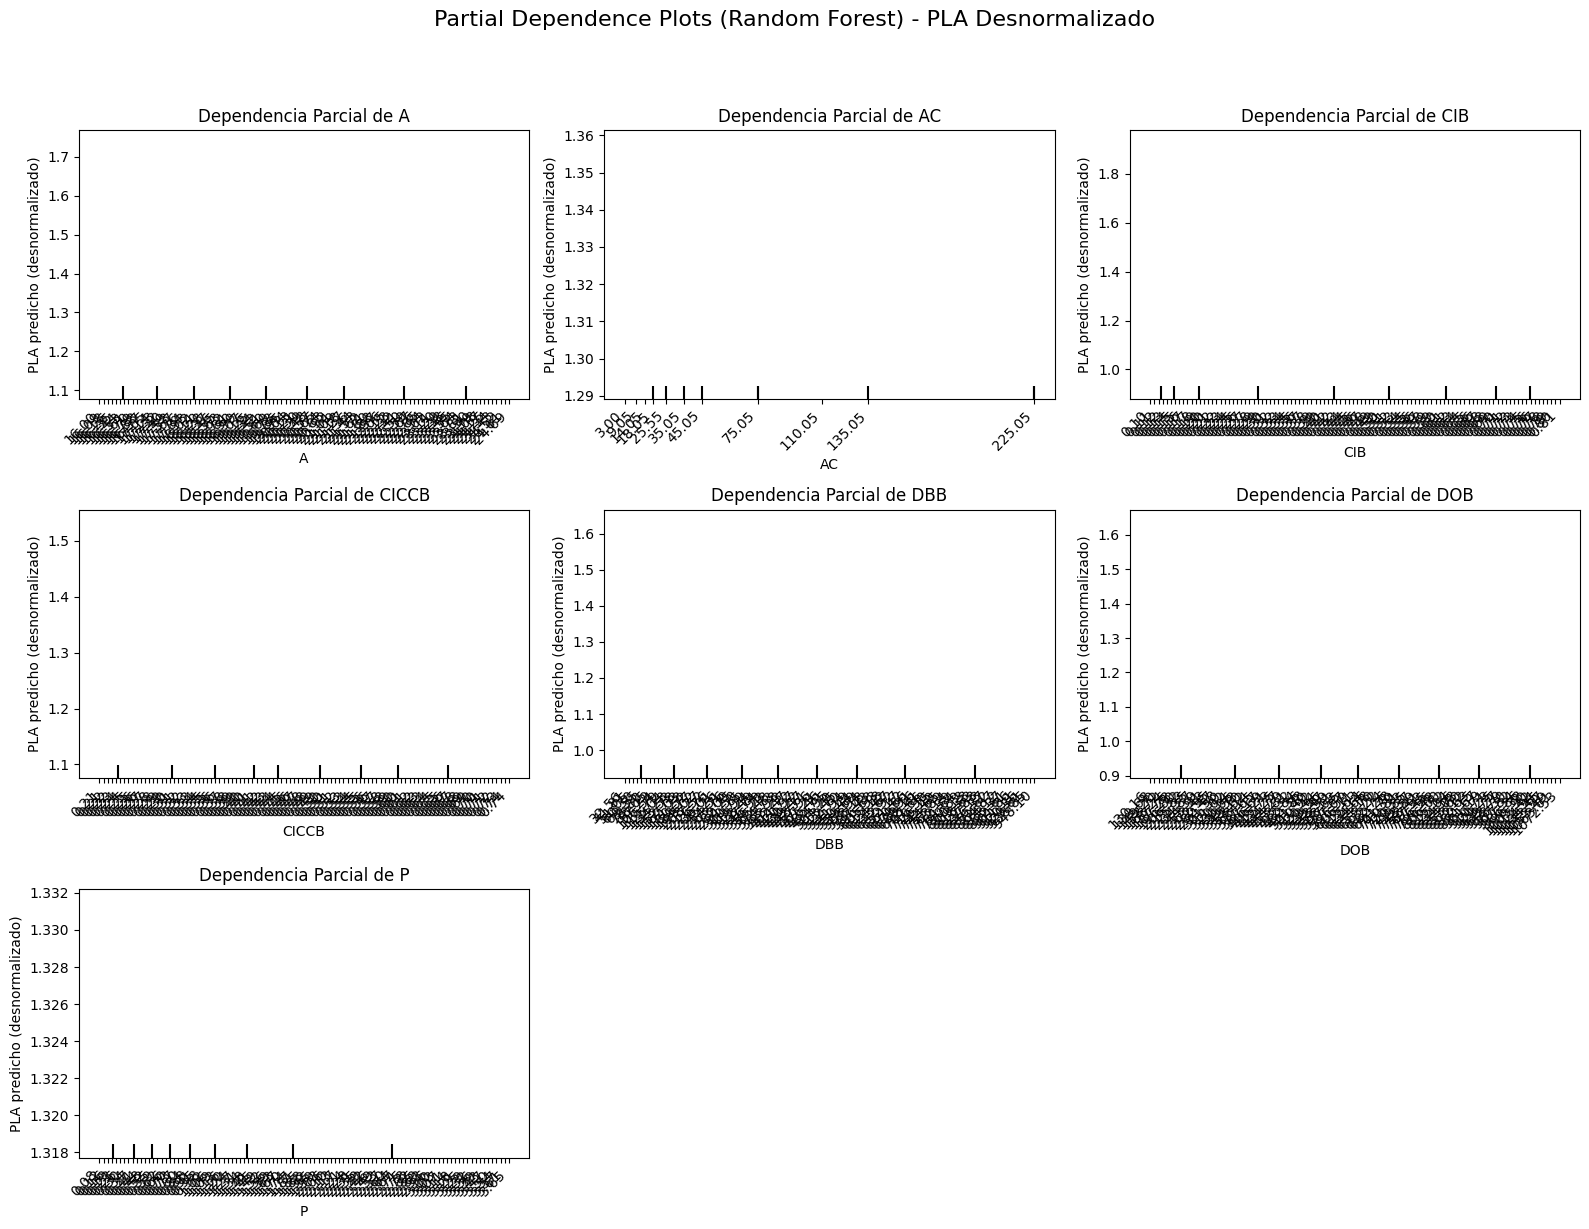

In [103]:
# --- FILTRAR LAS CARACTERÍSTICAS PARA QUE SOLO SE INCLUYAN LAS ESCALADAS ---
# Excluir las variables que no están en el scaler
# Podemos hacerlo por el nombre o por la pertenencia a la lista
# Opción 1: Por lista
scaler_column_order = ['PLA', 'A', 'AC', 'CIB', 'CICCB', 'DBB', 'DOB', 'P']
n_features_scaler = loaded_scaler.data_min_.shape[0]
top_features = features_to_plot
features_to_plot = [f for f in top_features if f in scaler_column_order[1:]] # Excluir 'PLA' de la lista de características
print(f"\nGenerando PDPs para las características: {features_to_plot}")

# Opción 2: Por prefijo (solo si tus nombres de columnas son consistentes)
# features_to_plot = [f for f in top_features if not f.startswith(('CUS', 'OC'))]
# print(f"\nGenerando PDPs para las características (filtradas por prefijo): {features_to_plot}")


# --- Ajustes para layout dinámico ---
n_features = len(features_to_plot)
if n_features == 0:
    print("ADVERTENCIA: No hay características numéricas para graficar PDPs. Saliendo.")
    exit()

n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axs = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axs = axs.flatten()

# --- CREACIÓN DE PDPs ---
display = PartialDependenceDisplay.from_estimator(
    estimator=modelo_rf_grid.best_estimator_,
    X=X_train,
    features=features_to_plot,
    kind='average',
    n_jobs=-1,
    ax=axs[:n_features],
)

# --- Bucle para desnormalizar y etiquetar ---
for i in range(len(features_to_plot)):
    current_ax = axs[i]
    if current_ax is None:
        continue

    feature_name = features_to_plot[i]

    # --- DESNORMALIZAR EL EJE Y ---
    pdp_line = current_ax.get_lines()[0]
    pdp_y = pdp_line.get_ydata()
    ymin_scaled_pdp = np.min(pdp_y)
    ymax_scaled_pdp = np.max(pdp_y)
    
    # --- Aumentar el rango del eje Y para una mejor visualización ---
    y_range = ymax_scaled_pdp - ymin_scaled_pdp
    
    # Si el rango es 0 (línea recta), usar un valor predefinido
    if y_range == 0:
        y_range = 0.05 
    
    margin_scaled = y_range * 0.2  # Margen del 20%
    ymin_scaled_pdp -= margin_scaled
    ymax_scaled_pdp += margin_scaled
    
    # Desnormalización del eje Y
    if DESNORMALIZAR_PDPS:
        ymin_desnormalized = ymin_scaled_pdp * range_pla + min_pla
        ymax_desnormalized = ymax_scaled_pdp * range_pla + min_pla
        current_ax.set_ylim(ymin_desnormalized, ymax_desnormalized)
        current_ax.set_ylabel('PLA predicho (desnormalizado)')
    else:
        current_ax.set_ylabel('PLA predicho (escalado)')

    # --- DESNORMALIZAR EL EJE X ---
    pdp_x = pdp_line.get_xdata()
    
    if DESNORMALIZAR_PDPS:
        feature_index = scaler_column_order.index(feature_name)
        
        x_desnormalized = loaded_scaler.inverse_transform(np.zeros((len(pdp_x), n_features_scaler)))
        x_desnormalized[:, feature_index] = pdp_x
        x_desnormalized = loaded_scaler.inverse_transform(x_desnormalized)[:, feature_index]
        
        new_xticks = pdp_x
        new_xticklabels = [f'{val:.2f}' for val in x_desnormalized]

        current_ax.set_xticks(new_xticks)
        current_ax.set_xticklabels(new_xticklabels, rotation=45, ha='right')
        current_ax.set_xlabel(feature_name)
    else:
        current_ax.set_xlabel(feature_name)

    current_ax.set_title(f'Dependencia Parcial de {feature_name}')

# Ocultar ejes sobrantes
for i in range(n_features, len(axs)):
    if axs[i] is not None:
        axs[i].set_visible(False)

plt.suptitle(
    f'Partial Dependence Plots (Random Forest) - PLA {"Desnormalizado" if DESNORMALIZAR_PDPS else "Escalado"}',
    y=1.02, fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.98])
# plt.savefig(os.path.join(parent_directory, 'images','PDPs.png'), bbox_inches='tight', dpi=300)
plt.show()


In [80]:
print(X_train.head())
print(X_train.shape)
print(min_pla)
print(range_pla)

print(X_train.describe())

              A        AC       CIB     CICCB       DBB       DOB         P  \
48196  0.634369  0.324476  0.101781  0.291697  0.484058  0.605235  0.036417   
31410  0.721612  0.027246  0.778726  0.541413  0.138255  0.208782  0.020722   
23835  0.534206  1.000000  0.043877  0.236189  0.285055  0.631355  0.000000   
53962  0.584288  0.324476  0.401558  0.193533  0.679098  0.738164  0.058812   
45212  0.805616  1.000000  0.816241  0.443402  0.213456  0.300115  0.032442   

       CUS_1  CUS_2  CUS_3  CUS_4  CUS_5  OC_1  OC_2  OC_3  OC_4  
48196    0.0    0.0    0.0    0.0    1.0   1.0   0.0   0.0   0.0  
31410    0.0    1.0    0.0    0.0    0.0   0.0   0.0   0.0   1.0  
23835    1.0    0.0    0.0    0.0    0.0   0.0   0.0   0.0   1.0  
53962    0.0    0.0    0.0    1.0    0.0   1.0   0.0   0.0   0.0  
45212    1.0    0.0    0.0    0.0    0.0   0.0   0.0   0.0   1.0  
(51476, 16)
0.0
9.280739784240724
                  A            AC           CIB         CICCB           DBB  \
count  514

In [45]:
print(f"Tipo de modelo_rf_grid.best_estimator_: {type(modelo_rf_grid.best_estimator_)}")
print(f"¿Modelo RF realmente ajustado?: {hasattr(modelo_rf_grid.best_estimator_, 'estimators_') and len(modelo_rf_grid.best_estimator_.estimators_) > 0}")
print(f"Número de características de entrada del modelo: {modelo_rf_grid.best_estimator_.n_features_in_ if hasattr(modelo_rf_grid.best_estimator_, 'n_features_in_') else 'N/A'}")

Tipo de modelo_rf_grid.best_estimator_: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
¿Modelo RF realmente ajustado?: True
Número de características de entrada del modelo: 16


In [46]:
print("\n--- Estadísticas de X_train (escalado) ---")
print(X_train.head())
print(X_train.describe())
print(f"¿Hay NaNs en X_train? {X_train.isnull().sum().sum() > 0}")


--- Estadísticas de X_train (escalado) ---
              A        AC       CIB     CICCB       DBB       DOB         P  \
48196  0.634369  0.324476  0.101781  0.291697  0.484058  0.605235  0.036417   
31410  0.721612  0.027246  0.778726  0.541413  0.138255  0.208782  0.020722   
23835  0.534206  1.000000  0.043877  0.236189  0.285055  0.631355  0.000000   
53962  0.584288  0.324476  0.401558  0.193533  0.679098  0.738164  0.058812   
45212  0.805616  1.000000  0.816241  0.443402  0.213456  0.300115  0.032442   

       CUS_1  CUS_2  CUS_3  CUS_4  CUS_5  OC_1  OC_2  OC_3  OC_4  
48196    0.0    0.0    0.0    0.0    1.0   1.0   0.0   0.0   0.0  
31410    0.0    1.0    0.0    0.0    0.0   0.0   0.0   0.0   1.0  
23835    1.0    0.0    0.0    0.0    0.0   0.0   0.0   0.0   1.0  
53962    0.0    0.0    0.0    1.0    0.0   1.0   0.0   0.0   0.0  
45212    1.0    0.0    0.0    0.0    0.0   0.0   0.0   0.0   1.0  
                  A            AC           CIB         CICCB           DBB  \


In [47]:
print(f"\nColumnas en X_train: {X_train.columns.tolist()}")
print(f"Características a plotear: {features_to_plot}")
# Add a manual check
for feat in features_to_plot:
    if feat not in X_train.columns:
        print(f"ERROR: La característica '{feat}' no existe en X_train.columns")


Columnas en X_train: ['A', 'AC', 'CIB', 'CICCB', 'DBB', 'DOB', 'P', 'CUS_1', 'CUS_2', 'CUS_3', 'CUS_4', 'CUS_5', 'OC_1', 'OC_2', 'OC_3', 'OC_4']
Características a plotear: ['CIB', 'DOB', 'A', 'CICCB', 'DBB', 'P', 'AC']


In [48]:
print(f"\nmin_pla (desnormalización): {min_pla}")
print(f"range_pla (desnormalización): {range_pla}")
if range_pla == 0:
    print("ADVERTENCIA: range_pla es cero. El target 'PLA' no tuvo variación en los datos de escalado.")


min_pla (desnormalización): 0.0
range_pla (desnormalización): 9.280739784240724


In [ ]:
# Para predecir con los valores de DOB cambiados. Solo esos valores. Poner DOB al máximo.

DataFrame combinado (antes de limpieza):        POINT_X       POINT_Y       A                Tipo       CIB     CICCB  \
0  727840.7057  4.360437e+06 -9999.0  Borde_Area_Estudio  0.360414  0.291086   
1  727850.7057  4.360437e+06 -9999.0  Borde_Area_Estudio  0.360151  0.290254   
2  727860.7057  4.360437e+06 -9999.0  Borde_Area_Estudio  0.359883  0.289380   
3  727870.7057  4.360437e+06 -9999.0  Borde_Area_Estudio  0.359611  0.288463   
4  727880.7057  4.360437e+06 -9999.0  Borde_Area_Estudio  0.359335  0.287504   

          DBB          DOB       P  PLA  
0  972.218018  5026.410156 -9999.0  NaN  
1  964.281982  5031.879883 -9999.0  NaN  
2  956.351990  5037.370117 -9999.0  NaN  
3  948.429016  5042.879883 -9999.0  NaN  
4  940.510986  5048.399902 -9999.0  NaN  
Se eliminaron 121092 filas con valores -9999 o sin PLA.
Municipios incluidos: ['Catarroja' 'Massanassa']


C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


[Nuevos municipios] R²: -4.3006, MSE: 1.4588, RMSE: 1.2078


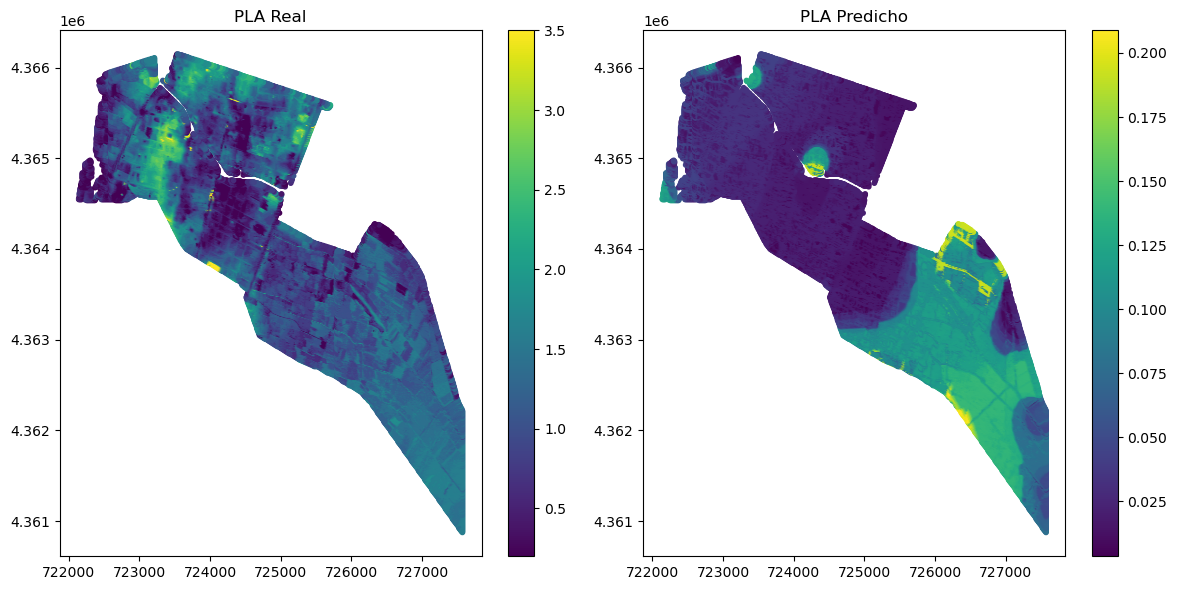

In [23]:
##############################
# PREDICCIÓN EN MUNICIPIOS NUEVOS
##############################

import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_val_score

# =======================
# 1. Rutas y carga de scaler + modelo
# =======================
carpeta_csv = os.path.join(parent_directory, "data", "variables", "nuevas_var")
scaler_path = os.path.join(parent_directory, "data", "min_max_scaler_imp.pkl")
loaded_scaler = joblib.load(scaler_path)

# si ya lo tienes cargado en memoria, usa directamente `modelo_rf_grid`
# modelo_rf_grid = joblib.load("ruta_a_tu_modelo.pkl")

# =======================
# 2. Leer y juntar CSV
# =======================
dataframes = []
for file in os.listdir(carpeta_csv):
    if file.endswith(".csv") and file.startswith("Variable_"):
        var_name = file.split("_")[1].replace(".csv", "")  # ej: "Variable_A.csv" -> "A"
        df = pd.read_csv(os.path.join(carpeta_csv, file))

        # Renombrar columnas
        df = df.rename(columns={
            "Eje_X": "POINT_X",
            "Eje_Y": "POINT_Y",
            "RASTERVALU": var_name
        })

        dataframes.append(df[["POINT_X", "POINT_Y", var_name, "Tipo"]])

# Unir todos por coordenadas
df_final = dataframes[0]
for df in dataframes[1:]:
    df_final = pd.merge(df_final, df, on=["POINT_X", "POINT_Y", "Tipo"], how="inner")

print("DataFrame combinado (antes de limpieza):", df_final.head())

# =======================
# 3. Limpieza de datos
# =======================
filas_iniciales = len(df_final)

# Eliminar filas con -9999
df_final = df_final[(df_final != -9999).all(axis=1)]

# Eliminar filas sin PLA
df_final = df_final.dropna(subset=["PLA"])

filas_eliminadas = filas_iniciales - len(df_final)
print(f"Se eliminaron {filas_eliminadas} filas con valores -9999 o sin PLA.")

# Filtrar solo Massanassa y Catarroja
df_final = df_final[df_final["Tipo"].isin(["Massanassa", "Catarroja"])]
print("Municipios incluidos:", df_final["Tipo"].unique())

# =======================
# 4. Preparar X e y
# =======================
variables_modelo = ["A", "CIB", "CICCB", "DBB", "DOB", "P"]
X = df_final[variables_modelo]
y = df_final["PLA"]
coords = df_final[["POINT_X", "POINT_Y"]].copy()

# =======================
# 5. Escalar X
# =======================
X_full = pd.DataFrame(0, index=df_final.index,
                      columns=['PLA','A','CIB','CICCB','DBB','DOB','P'])
X_full[variables_modelo] = X
X_scaled = loaded_scaler.transform(X_full)
X_scaled = X_scaled[:, [1,2,3,4,5,6]]

# =======================
# 6. Predicciones con RF entrenado
# =======================
y_pred = modelo_rf_grid.predict(X_scaled)

# Evaluación
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print(f"[Nuevos municipios] R²: {r2:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}")

# Mapa
fig, axes = plt.subplots(1, 2, figsize=(12,6))
sc1 = axes[0].scatter(coords["POINT_X"], coords["POINT_Y"], c=y, cmap="viridis", s=10)
axes[0].set_title("PLA Real")
plt.colorbar(sc1, ax=axes[0])
sc2 = axes[1].scatter(coords["POINT_X"], coords["POINT_Y"], c=y_pred, cmap="viridis", s=10)
axes[1].set_title("PLA Predicho")
plt.colorbar(sc2, ax=axes[1])
plt.tight_layout()
plt.show()




In [29]:

##############################
# VALIDACIÓN CRUZADA ESPACIAL
##############################

# Función para hacer clusters espaciales
from sklearn.cluster import KMeans

def spatial_cv_rf(df, variables, n_splits=10):
    """
    Entrena un RandomForest con validación cruzada espacial usando clusters de coordenadas.
    """
    X = df[variables]
    y = df["PLA"]
    coords = df[["POINT_X", "POINT_Y"]].copy()

    # Crear clusters espaciales (KMeans sobre coordenadas)
    kmeans = KMeans(n_clusters=n_splits, random_state=42)
    spatial_groups = kmeans.fit_predict(coords)

    # Escalar con el mismo scaler
    X_full = pd.DataFrame(0, index=df.index,
                          columns=['PLA','A','CIB','CICCB','DBB','DOB','P'])
    X_full[variables] = X
    X_scaled = loaded_scaler.transform(X_full)
    X_scaled = X_scaled[:, [1,2,3,4,5,6]]

    # Definir modelo RF
    rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)

    # CV espacial
    cv = GroupKFold(n_splits=n_splits)
    scores = cross_val_score(rf, X_scaled, y, cv=cv, groups=spatial_groups,
                             scoring="r2", n_jobs=-1)
    return scores

# Caso 1: Solo Paiporta
df_paiporta = data
print(data.head(5))
scores_paiporta = spatial_cv_rf(df_paiporta, variables_modelo)
print(f"Validación espacial solo Paiporta R² medio: {np.mean(scores_paiporta):.4f}")

# Caso 2: Paiporta + Massanassa -> predecir Catarroja
df_train = df_final[df_final["Tipo"].isin(["Paiporta","Massanassa"])]
df_test = df_final[df_final["Tipo"]=="Catarroja"]

scores_pm = spatial_cv_rf(df_train, variables_modelo)
print(f"Entrenado en Paiporta+Massanassa, validación espacial R² medio: {np.mean(scores_pm):.4f}")

# Caso 3: Paiporta + Catarroja -> predecir Massanassa
df_train = df_final[df_final["Tipo"].isin(["Paiporta","Catarroja"])]
df_test = df_final[df_final["Tipo"]=="Massanassa"]

scores_pc = spatial_cv_rf(df_train, variables_modelo)
print(f"Entrenado en Paiporta+Catarroja, validación espacial R² medio: {np.mean(scores_pc):.4f}")


         POINT_X       POINT_Y  PLA         A       CIB     CICCB       DBB  \
0  722396.507981  4.365860e+06  0.0  0.604254  0.203910  0.390004  0.620621   
1  722404.245816  4.365860e+06  0.0  0.581583  0.201362  0.388246  0.614835   
2  722411.983652  4.365860e+06  0.0  0.581583  0.198815  0.386458  0.610494   
3  722396.502336  4.365868e+06  0.0  0.609629  0.204328  0.391055  0.620342   
4  722404.240164  4.365868e+06  0.0  0.608561  0.201762  0.389291  0.614553   

        DOB         P  
0  0.000000  0.077332  
1  0.788748  0.089864  
2  0.783177  0.089864  
3  0.000000  0.051674  
4  0.788748  0.062030  
Validación espacial solo Paiporta R² medio: -0.1425
Entrenado en Paiporta+Massanassa, validación espacial R² medio: 0.1877
Entrenado en Paiporta+Catarroja, validación espacial R² medio: -0.4133


In [34]:
##################### ALPHA EARTH


from pyproj import Transformer

# Transformer ETRS89/UTM zone 30N -> WGS84
transformer = Transformer.from_crs("EPSG:25830", "EPSG:4326", always_xy=True)

def transformar_coords(df):
    """
    Convierte POINT_X, POINT_Y de ETRS89/UTM 30N a WGS84 (lon, lat).
    """
    lon, lat = transformer.transform(df["POINT_X"].values, df["POINT_Y"].values)
    df = df.copy()  # asegurar copia
    df.loc[:, "lon"] = lon
    df.loc[:, "lat"] = lat
    return df

In [31]:
df_paiporta = pd.read_csv(os.path.join(parent_directory, 'data', "data_con_embeddings.csv"))

# Quitar columnas innecesarias
df_paiporta = df_paiporta.drop(columns=["CUS", "OC", "AC"], errors="ignore")

# Asegúrate de tener coordenadas y PLA
print(df_paiporta.head())

         POINT_X       POINT_Y  PLA         A       CIB     CICCB       DBB  \
0  722396.507981  4.365860e+06  0.0  0.604254  0.203910  0.390004  0.620621   
1  722404.245816  4.365860e+06  0.0  0.581583  0.201362  0.388246  0.614835   
2  722411.983652  4.365860e+06  0.0  0.581583  0.198815  0.386458  0.610494   
3  722396.502336  4.365868e+06  0.0  0.609629  0.204328  0.391055  0.620342   
4  722404.240164  4.365868e+06  0.0  0.608561  0.201762  0.389291  0.614553   

        DOB         P  CUS_1  ...    emb_54    emb_55    emb_56    emb_57  \
0  0.000000  0.077332    0.0  ... -0.012057 -0.206936  0.032541 -0.051734   
1  0.788748  0.089864    1.0  ... -0.012057 -0.206936  0.032541 -0.059116   
2  0.783177  0.089864    1.0  ... -0.007443 -0.192910  0.024606 -0.084214   
3  0.000000  0.051674    1.0  ... -0.012057 -0.206936  0.032541 -0.051734   
4  0.788748  0.062030    1.0  ... -0.012057 -0.206936  0.032541 -0.059116   

     emb_58    emb_59    emb_60    emb_61    emb_62    emb_63 

In [35]:
# Transformar coords primero
df_massanassa = transformar_coords(df_final[df_final["Tipo"]=="Massanassa"].copy())
df_catarroja = transformar_coords(df_final[df_final["Tipo"]=="Catarroja"].copy())


In [36]:
# 1. Autenticación e inicio de Earth Engine
import ee
ee.Authenticate()
ee.Initialize()

Enter verification code:  4/1AVMBsJj_A2j2Z6uRBuGAAuapNybVt9v_ikviXIPXWhUF65X1HQIoxGxt-rw



Successfully saved authorization token.


In [37]:
# 3. Función para obtener embeddings AlphaEarth 2024
def fetch_embedding_2024(lon, lat):
    try:
        pt = ee.Geometry.Point([lon, lat])
        collection = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL") \
                        .filterDate("2024-01-01", "2025-01-01") \
                        .filterBounds(pt)
        
        # Si no hay imágenes, saltar
        if collection.size().getInfo() == 0:
            return [None] * 64
        
        img = collection.first()
        band_names = [f"A{str(i).zfill(2)}" for i in range(64)]
        vals = img.select(band_names).reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=pt,
            scale=10
        ).getInfo()
        
        return [vals.get(b) for b in band_names]
    
    except Exception as e:
        print(f"Error en punto ({lon}, {lat}): {e}")
        return [None] * 64


In [38]:
# Massanassa
embeddings_list = []
for idx, row in df_massanassa.iterrows():
    emb = fetch_embedding_2024(row['lon'], row['lat'])  # OJO ahora usamos lon/lat
    embeddings_list.append(emb)

emb_df = pd.DataFrame(embeddings_list, columns=[f"emb_{i}" for i in range(64)])
df_massanassa_emb = pd.concat([df_massanassa.reset_index(drop=True), emb_df], axis=1)

# Catarroja
embeddings_list = []
for idx, row in df_catarroja.iterrows():
    emb = fetch_embedding_2024(row['lon'], row['lat'])
    embeddings_list.append(emb)

emb_df = pd.DataFrame(embeddings_list, columns=[f"emb_{i}" for i in range(64)])
df_catarroja_emb = pd.concat([df_catarroja.reset_index(drop=True), emb_df], axis=1)

In [39]:
df_massanassa_emb.to_csv(os.path.join(parent_directory, "data", "massanassa_con_embeddings.csv"), index=False)
df_catarroja_emb.to_csv(os.path.join(parent_directory, "data", "catarroja_con_embeddings.csv"), index=False)

In [44]:
import os
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.cluster import KMeans

# =======================
# 1. Cargar datasets con embeddings
# =======================
#df_paiporta = pd.read_csv(os.path.join(parent_directory, 'data', "data_con_embeddings.csv"))
#df_massanassa = pd.read_csv(os.path.join(parent_directory, "data", "massanassa_con_embeddings.csv"))
#df_catarroja = pd.read_csv(os.path.join(parent_directory, "data", "catarroja_con_embeddings.csv"))

# Añadir la columna Tipo para diferenciarlos
df_paiporta["Tipo"] = "Paiporta"
df_massanassa_emb["Tipo"] = "Massanassa"
df_catarroja_emb["Tipo"] = "Catarroja"

# Concatenar en un único dataset
df_all = pd.concat([df_paiporta, df_massanassa, df_catarroja], ignore_index=True)

print("Dataset combinado:", df_all.shape)
print("Columnas disponibles:", df_all.columns[:22], "...")

# =======================
# 2. Definir variables de modelo (excluir coords, target y CUS/OC/AC)
# =======================
variables_modelo = [
    c for c in df_all.columns
    if c not in ["POINT_X", "POINT_Y", "lon", "lat", "Tipo", "PLA"]
    and not (c.startswith("CUS_") or c.startswith("OC_") or c.startswith("AC_"))
]

print("Variables en el modelo:", variables_modelo[:15], "... total:", len(variables_modelo))


Dataset combinado: (160442, 85)
Columnas disponibles: Index(['POINT_X', 'POINT_Y', 'PLA', 'A', 'CIB', 'CICCB', 'DBB', 'DOB', 'P',
       'CUS_1', 'CUS_2', 'CUS_3', 'CUS_4', 'CUS_5', 'OC_1', 'OC_2', 'OC_3',
       'OC_4', 'lon', 'lat', 'emb_0', 'emb_1'],
      dtype='object') ...
Variables en el modelo: ['A', 'CIB', 'CICCB', 'DBB', 'DOB', 'P', 'emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7', 'emb_8'] ... total: 70


In [45]:
# =======================
# 3. Función validación espacial
# =======================
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_val_score

def spatial_cv_rf(df, variables, n_splits=10):
    X = df[variables].fillna(0)  
    y = df["PLA"]
    coords = df[["POINT_X", "POINT_Y"]].copy()

    # Clustering espacial
    kmeans = KMeans(n_clusters=n_splits, random_state=42)
    spatial_groups = kmeans.fit_predict(coords)

    rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)

    cv = GroupKFold(n_splits=n_splits)
    scores = cross_val_score(rf, X, y, cv=cv, groups=spatial_groups,
                             scoring="r2", n_jobs=-1)
    return scores

# =======================
# 4. Evaluaciones
# =======================

# Caso 1: Solo Paiporta
scores_paiporta = spatial_cv_rf(df_paiporta, variables_modelo)
print(f"Validación espacial solo Paiporta R² medio: {np.mean(scores_paiporta):.4f}")

# Caso 2: Paiporta + Massanassa -> validar Catarroja
df_train_pm = df_all[df_all["Tipo"].isin(["Paiporta","Massanassa"])]
scores_pm = spatial_cv_rf(df_train_pm, variables_modelo)
print(f"Entrenado en Paiporta+Massanassa, validación espacial R² medio: {np.mean(scores_pm):.4f}")

# Caso 3: Paiporta + Catarroja -> validar Massanassa
df_train_pc = df_all[df_all["Tipo"].isin(["Paiporta","Catarroja"])]
scores_pc = spatial_cv_rf(df_train_pc, variables_modelo)
print(f"Entrenado en Paiporta+Catarroja, validación espacial R² medio: {np.mean(scores_pc):.4f}")

Validación espacial solo Paiporta R² medio: 0.0331
Entrenado en Paiporta+Massanassa, validación espacial R² medio: -0.1721
Entrenado en Paiporta+Catarroja, validación espacial R² medio: -0.3074


In [55]:
import lightgbm as lgb
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans
from sklearn.model_selection import GroupKFold
import numpy as np

def spatial_cv_gbm(df, variables, n_splits=5):
    """
    Entrena LightGBM con validación cruzada espacial.
    """
    X = df[variables].fillna(0).values
    y = df["PLA"].values
    coords = df[["POINT_X", "POINT_Y"]].values

    # Clustering espacial
    kmeans = KMeans(n_clusters=n_splits, random_state=42)
    groups = kmeans.fit_predict(coords)

    cv = GroupKFold(n_splits=n_splits)
    scores = []

    for train_idx, test_idx in cv.split(X, y, groups):
        Xtr, Xte = X[train_idx], X[test_idx]
        ytr, yte = y[train_idx], y[test_idx]

        # Dataset LightGBM
        dtrain = lgb.Dataset(Xtr, label=ytr)
        dvalid = lgb.Dataset(Xte, label=yte, reference=dtrain)

        params = {
            "objective": "regression",
            "metric": "rmse",
            "boosting_type": "gbdt",
            "num_leaves": 64,
            "learning_rate": 0.05,
            "feature_fraction": 0.8,
            "bagging_fraction": 0.8,
            "bagging_freq": 5,
            "verbose": -1,
            "seed": 42
        }

        model = lgb.train(
            params,
            dtrain,
            num_boost_round=500,
            valid_sets=[dvalid],  # ahora solo valid
            #verbose_eval=False    # silenciar output
        )

        ypred = model.predict(Xte)
        scores.append(r2_score(yte, ypred))

    return np.mean(scores)


# ==============================
# EXPERIMENTOS
# ==============================

# Variables (sin CUS, OC, AC, coords, Tipo)
excluded = ["POINT_X","POINT_Y","lon","lat","PLA","Tipo"] + [c for c in df_all.columns if c.startswith(("CUS","OC","AC"))]
variables = [c for c in df_all.columns if c not in excluded]

# Caso 1: Solo Paiporta
r2_paiporta = spatial_cv_gbm(df_paiporta, variables)
print(f"Validación espacial GBM solo Paiporta R² medio: {r2_paiporta:.4f}")

# Caso 2: Paiporta + Massanassa → validar Catarroja
df_train_pm = df_all[df_all["Tipo"].isin(["Paiporta","Massanassa"])]
r2_pm = spatial_cv_gbm(df_train_pm, variables)
print(f"Entrenado en Paiporta+Massanassa, validación espacial R² medio: {r2_pm:.4f}")

# Caso 3: Paiporta + Catarroja → validar Massanassa
df_train_pc = df_all[df_all["Tipo"].isin(["Paiporta","Catarroja"])]
r2_pc = spatial_cv_gbm(df_train_pc, variables)
print(f"Entrenado en Paiporta+Catarroja, validación espacial R² medio: {r2_pc:.4f}")



Validación espacial GBM solo Paiporta R² medio: -0.0063
Entrenado en Paiporta+Massanassa, validación espacial R² medio: -2.1996
Entrenado en Paiporta+Catarroja, validación espacial R² medio: -2.0184


Primera prueba, Light GBM con validación espacial por puntos, y todas las variables.
Validación espacial GBM solo Paiporta R² medio: -0.0063
Entrenado en Paiporta+Massanassa, validación espacial R² medio: -2.1996
Entrenado en Paiporta+Catarroja, validación espacial R² medio: -2.0184

Probar haciendo PCA. 
PCA=15
[GBM+PCA] Validación espacial solo Paiporta R² medio: -0.1357
[GBM+PCA] Entrenado en Paiporta+Massanassa → R² medio: -14.5704
[GBM+PCA] Entrenado en Paiporta+Catarroja → R² medio: -1.5579
PCA=20
[GBM+PCA] Validación espacial solo Paiporta R² medio: -0.2104
[GBM+PCA] Entrenado en Paiporta+Massanassa → R² medio: -18.1607
[GBM+PCA] Entrenado en Paiporta+Catarroja → R² medio: -2.8301
PCA=10
[GBM+PCA] Validación espacial solo Paiporta R² medio: -0.1328
[GBM+PCA] Entrenado en Paiporta+Massanassa → R² medio: -16.8849
[GBM+PCA] Entrenado en Paiporta+Catarroja → R² medio: -1.6012
PCA=5
[GBM+PCA] Validación espacial solo Paiporta R² medio: -0.1714
[GBM+PCA] Entrenado en Paiporta+Massanassa → R² medio: -19.6172
[GBM+PCA] Entrenado en Paiporta+Catarroja → R² medio: -0.9728

In [63]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

# ==============================
# 1. Selección de variables
# ==============================
excluded = ["POINT_X","POINT_Y","lon","lat","PLA","Tipo"] + \
           [c for c in df_all.columns if c.startswith(("CUS","OC","AC"))]
variables = [c for c in df_all.columns if c not in excluded]

# Separar embeddings
embeddings = [c for c in variables if c.startswith("emb_")]
geo_vars = [c for c in variables if c not in embeddings]

print(f"Variables geoespaciales: {geo_vars}")
print(f"Embeddings detectados: {len(embeddings)}")

# ==============================
# 2. Función PCA + LightGBM CV
# ==============================
def spatial_cv_gbm_pca(df, geo_vars, emb_vars, n_pca=15, n_splits=5):
    # Separar X, y
    X_geo = df[geo_vars].fillna(0).values
    X_emb = df[emb_vars].fillna(0).values
    y = df["PLA"].values
    coords = df[["POINT_X","POINT_Y"]].values

    # PCA embeddings
    pca = PCA(n_components=min(n_pca, X_emb.shape[1]))
    X_emb_pca = pca.fit_transform(X_emb)

    # Concatenar
    X = np.hstack([X_geo, X_emb_pca])

    # Escalar
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Clustering espacial
    kmeans = KMeans(n_clusters=n_splits, random_state=42)
    groups = kmeans.fit_predict(coords)

    # CV
    cv = GroupKFold(n_splits=n_splits)
    scores = []
    for train_idx, test_idx in cv.split(X, y, groups):
        Xtr, Xte = X[train_idx], X[test_idx]
        ytr, yte = y[train_idx], y[test_idx]

        train_data = lgb.Dataset(Xtr, label=ytr)
        valid_data = lgb.Dataset(Xte, label=yte, reference=train_data)

        params = {
            "objective": "regression",
            "metric": "rmse",
            "boosting_type": "gbdt",
            "num_leaves": 64,
            "learning_rate": 0.05,
            "feature_fraction": 0.8,
            "bagging_fraction": 0.8,
            "bagging_freq": 5,
            "verbose": -1,
            "seed": 42
        }

        model = lgb.train(params, train_data, num_boost_round=500)

        ypred = model.predict(Xte)
        scores.append(r2_score(yte, ypred))

    return np.mean(scores)

# ==============================
# 3. EXPERIMENTOS
# ==============================

# Caso 1: Solo Paiporta

r2_paiporta = spatial_cv_gbm_pca(df_paiporta, geo_vars, embeddings, n_pca=5)
print(f"[GBM+PCA] Validación espacial solo Paiporta R² medio: {r2_paiporta:.4f}")

# Caso 2: Paiporta + Massanassa
df_train_pm = df_all[df_all["Tipo"].isin(["Paiporta","Massanassa"])].copy()
r2_pm = spatial_cv_gbm_pca(df_train_pm, geo_vars, embeddings, n_pca=5)
print(f"[GBM+PCA] Entrenado en Paiporta+Massanassa → R² medio: {r2_pm:.4f}")

# Caso 3: Paiporta + Catarroja
df_train_pc = df_all[df_all["Tipo"].isin(["Paiporta","Catarroja"])].copy()
r2_pc = spatial_cv_gbm_pca(df_train_pc, geo_vars, embeddings, n_pca=5)
print(f"[GBM+PCA] Entrenado en Paiporta+Catarroja → R² medio: {r2_pc:.4f}")


Variables geoespaciales: ['A', 'CIB', 'CICCB', 'DBB', 'DOB', 'P']
Embeddings detectados: 64
[GBM+PCA] Validación espacial solo Paiporta R² medio: -0.1714
[GBM+PCA] Entrenado en Paiporta+Massanassa → R² medio: -19.6172
[GBM+PCA] Entrenado en Paiporta+Catarroja → R² medio: -0.9728


In [66]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.feature_selection import RFE
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans

# ==============================
# 1. Función evaluación RFE + Spatial CV
# ==============================
def evaluate_rfe(df, variables, n_features, n_splits=5):
    """
    Ejecuta RFE con LightGBM y validación cruzada espacial para un número dado de features.
    """
    X = df[variables].fillna(0).values
    y = df["PLA"].values
    coords = df[["POINT_X", "POINT_Y"]].values

    # Clustering espacial
    kmeans = KMeans(n_clusters=n_splits, random_state=42)
    groups = kmeans.fit_predict(coords)

    # Estimador base
    base_model = lgb.LGBMRegressor(
        objective="regression",
        num_leaves=32,
        learning_rate=0.1,
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    # RFE
    rfe = RFE(base_model, n_features_to_select=n_features, step=0.1)
    X_reduced = rfe.fit_transform(X, y)
    selected_features = np.array(variables)[rfe.support_]

    # Validación cruzada espacial
    cv = GroupKFold(n_splits=n_splits)
    scores = []
    for train_idx, test_idx in cv.split(X_reduced, y, groups):
        Xtr, Xte = X_reduced[train_idx], X_reduced[test_idx]
        ytr, yte = y[train_idx], y[test_idx]

        model = lgb.LGBMRegressor(
            objective="regression",
            num_leaves=32,
            learning_rate=0.1,
            n_estimators=500,
            random_state=42,
            n_jobs=-1
        )
        model.fit(Xtr, ytr)
        ypred = model.predict(Xte)
        scores.append(r2_score(yte, ypred))

    return np.mean(scores), selected_features


# ==============================
# 2. Loop para buscar el mejor número de features
# ==============================
def optimize_rfe(df, variables, candidates=[10, 20, 30, 40, 50], n_splits=5):
    results = {}
    best_score = -999
    best_n = None
    best_feats = None

    for n in candidates:
        print(f"\n🔎 Probando con {n} features...")
        score, feats = evaluate_rfe(df, variables, n, n_splits=n_splits)
        results[n] = score
        print(f"   → R² medio: {score:.4f}")

        if score > best_score:
            best_score = score
            best_n = n
            best_feats = feats

    print("\n==================== RESULTADOS ====================")
    for n, sc in results.items():
        print(f"{n} features → R² medio {sc:.4f}")
    print("====================================================")
    print(f"🏆 Mejor configuración: {best_n} features con R²={best_score:.4f}")

    return best_n, best_score, best_feats, results


# ==============================
# 3. Ejemplo de uso
# ==============================
excluded = ["POINT_X","POINT_Y","lon","lat","PLA","Tipo"] + \
           [c for c in df_all.columns if c.startswith(("CUS","OC","AC"))]
variables = [c for c in df_all.columns if c not in excluded]

# Caso 1: Solo Paiporta
best_n, best_score, best_feats, results = optimize_rfe(df_paiporta, variables, candidates=[10,20,30,40,50,60,70])




🔎 Probando con 10 features...


C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   → R² medio: -0.1680

🔎 Probando con 20 features...


C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   → R² medio: -0.1932

🔎 Probando con 30 features...


...

C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   → R² medio: -0.1197

🔎 Probando con 70 features...


C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   → R² medio: -0.0707

==================== RESULTADOS ====================
10 features → R² medio -0.1680
20 features → R² medio -0.1932
30 features → R² medio -0.1401
40 features → R² medio -0.1442
50 features → R² medio -0.1413
60 features → R² medio -0.1197
70 features → R² medio -0.0707
🏆 Mejor configuración: 70 features con R²=-0.0707


C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
features=30
[GBM+RFE] Validación espacial solo Paiporta R² medio: -0.1401
[GBM+RFE] Entrenado en Paiporta+Massanassa → R² medio: -3.3665
[GBM+RFE] Entrenado en Paiporta+Catarroja → R² medio: -3.9298

🏆 Mejor configuración: 70 features con R² medio=-0.0707

In [68]:
# --- GUARDAR CSVs DE MASSANASSA Y CATARROJA ---

import pandas as pd

# Filtrar municipios
df_massanassa = df_all[df_all["Tipo"] == "Massanassa"].copy()
df_catarroja  = df_all[df_all["Tipo"] == "Catarroja"].copy()
nombre_archivo_salida = "df_massanassa.csv"

df_massanassa.to_csv(os.path.join(parent_directory,'data',nombre_archivo_salida), index=False) # index=False evita guardar el índice de pandas como una columna

print(f"\nDataFrame combinado guardado exitosamente como '{nombre_archivo_salida}' en '{os.path.join(parent_directory,'data',nombre_archivo_salida)}'")

nombre_archivo_salida = "df_catarroja.csv"

df_massanassa.to_csv(os.path.join(parent_directory,'data',nombre_archivo_salida), index=False) # index=False evita guardar el índice de pandas como una columna

print(f"\nDataFrame combinado guardado exitosamente como '{nombre_archivo_salida}' en '{os.path.join(parent_directory,'data',nombre_archivo_salida)}'")




DataFrame combinado guardado exitosamente como 'df_massanassa.csv' en 'C:\Users\cuent\En-Peu\data\df_massanassa.csv'

DataFrame combinado guardado exitosamente como 'df_catarroja.csv' en 'C:\Users\cuent\En-Peu\data\df_catarroja.csv'


In [79]:
# Ajustar scaler de embeddings SOLO con Paiporta
emb_cols = [c for c in df_paiporta.columns if c.startswith("emb_")]
scaler_emb = StandardScaler()
scaler_emb.fit(df_paiporta[emb_cols].values)

# Guardar scaler de embeddings
joblib.dump(scaler_emb, (os.path.join(parent_directory,'data',"scaler_emb.pkl")))


import joblib
from sklearn.preprocessing import MinMaxScaler

geo_cols = ["A","CIB","CICCB","DBB","DOB","P"]

scaler_geo = MinMaxScaler()
scaler_geo.fit(df_paiporta[geo_cols])

joblib.dump(scaler_geo, os.path.join(parent_directory,'data',"min_max_scaler_imp_sin_pla.pkl"))
print("Scaler reentrenado y guardado correctamente (sin PLA).")


print("Scalers guardados.")

Scaler reentrenado y guardado correctamente (sin PLA).
Scalers guardados.


In [80]:
import joblib, numpy as np, pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# === Cargar datos y scalers ===
#df_paiporta   = pd.read_csv("paiporta.csv")
#df_massanassa = pd.read_csv("massanassa.csv")
#df_catarroja  = pd.read_csv("catarroja.csv")

scaler_geo = joblib.load(os.path.join(parent_directory,'data',"min_max_scaler_imp_sin_pla.pkl"))
scaler_emb = joblib.load(os.path.join(parent_directory,'data',"scaler_emb.pkl"))

geo_cols = ["A","CIB","CICCB","DBB","DOB","P"]
emb_cols = [c for c in df_paiporta.columns if c.startswith("emb_")]

def build_X(df, clip_geo=True):
    Xg = scaler_geo.transform(df[geo_cols])
    Xe = scaler_emb.transform(df[emb_cols])
    if clip_geo:
        Xg = np.clip(Xg, 0, 1)
    return np.hstack([Xg, Xe])

def report(y_true, y_pred, name):
    r2  = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name}: R²={r2:.4f} | RMSE={rmse:.6f} | MAE={mae:.6f}")

# === Construir X,y ===
X_paiporta, y_paiporta = build_X(df_paiporta), df_paiporta["PLA"].values
X_mass, y_mass = build_X(df_massanassa), df_massanassa["PLA"].values
X_cat,  y_cat  = build_X(df_catarroja),  df_catarroja["PLA"].values

# === Random Forest entrenado solo en Paiporta ===
rf = RandomForestRegressor(
    n_estimators=500, max_depth=25, max_features="sqrt",
    min_samples_split=3, min_samples_leaf=2, n_jobs=-1, random_state=42
)
rf.fit(X_paiporta, y_paiporta)

print("\n--- RF ---")
report(y_paiporta, rf.predict(X_paiporta), "Paiporta (train)")
report(y_mass, rf.predict(X_mass), "Massanassa")
report(y_cat,  rf.predict(X_cat),  "Catarroja")

# === XGBoost entrenado solo en Paiporta ===
gbm = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
gbm.fit(X_paiporta, y_paiporta)

print("\n--- GBM (XGBoost) ---")
report(y_paiporta, gbm.predict(X_paiporta), "Paiporta (train)")
report(y_mass, gbm.predict(X_mass), "Massanassa")
report(y_cat,  gbm.predict(X_cat),  "Catarroja")

C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\cuent\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



--- RF ---
Paiporta (train): R²=0.9861 | RMSE=0.008246 | MAE=0.003623
Massanassa: R²=-3.6822 | RMSE=1.257266 | MAE=1.115650
Catarroja: R²=-3.9101 | RMSE=1.127364 | MAE=1.009303

--- GBM (XGBoost) ---
Paiporta (train): R²=0.9705 | RMSE=0.012030 | MAE=0.008406
Massanassa: R²=-4.3464 | RMSE=1.343482 | MAE=1.212570
Catarroja: R²=-4.3252 | RMSE=1.174042 | MAE=1.063055


--- RF ---
Paiporta (train): R²=0.9861 | RMSE=0.008246 | MAE=0.003623
Massanassa: R²=-3.6822 | RMSE=1.257266 | MAE=1.115650
Catarroja: R²=-3.9101 | RMSE=1.127364 | MAE=1.009303

--- GBM (XGBoost) ---
Paiporta (train): R²=0.9705 | RMSE=0.012030 | MAE=0.008406
Massanassa: R²=-4.3464 | RMSE=1.343482 | MAE=1.212570
Catarroja: R²=-4.3252 | RMSE=1.174042 | MAE=1.063055

In [81]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb

# ========================
# 1. Función de evaluación
# ========================
def evaluate_model(model, X_train, y_train, X_test, y_test, name=""):
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_test  = model.predict(X_test)

    r2_train = r2_score(y_train, pred_train)
    r2_test  = r2_score(y_test, pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))
    mae_test  = mean_absolute_error(y_test, pred_test)

    print(f"\n--- {name} ---")
    print(f"Train R²={r2_train:.4f}")
    print(f"Test  R²={r2_test:.4f} | RMSE={rmse_test:.6f} | MAE={mae_test:.6f}")
    return r2_test

# ========================
# 2. Construir pipeline
# ========================
def make_pipeline(model_type="rf"):
    # columnas
    num_cols  = [c for c in df_paiporta.columns if c not in ["PLA","Tipo"]]
    cat_cols  = ["Tipo"]

    # transformaciones
    preproc = ColumnTransformer([
        ("num", MinMaxScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ])

    if model_type=="rf":
        model = RandomForestRegressor(
            n_estimators=800, max_depth=25, random_state=42, n_jobs=-1
        )
    else:
        model = xgb.XGBRegressor(
            n_estimators=1000, max_depth=8, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
        )

    pipe = Pipeline([
        ("preproc", preproc),
        ("model", model)
    ])
    return pipe

# ========================
# 3. Datos
# ========================
dfs = {
    "Paiporta": df_paiporta.copy(),
    "Massanassa": df_massanassa.copy(),
    "Catarroja": df_catarroja.copy()
}

# ========================
# 4. Experimentos
# ========================

# Caso A: Solo Paiporta → test en los otros dos
Xtr = dfs["Paiporta"].drop(columns=["PLA"])
ytr = dfs["Paiporta"]["PLA"]

for muni in ["Massanassa","Catarroja"]:
    Xte = dfs[muni].drop(columns=["PLA"])
    yte = dfs[muni]["PLA"]

    pipe_rf  = make_pipeline("rf")
    pipe_gbm = make_pipeline("gbm")

    evaluate_model(pipe_rf,  Xtr, ytr, Xte, yte, name=f"RF - Train Paiporta → Test {muni}")
    evaluate_model(pipe_gbm, Xtr, ytr, Xte, yte, name=f"GBM - Train Paiporta → Test {muni}")

# Caso B: Paiporta+Massanassa → test Catarroja
Xtr = pd.concat([dfs["Paiporta"], dfs["Massanassa"]]).drop(columns=["PLA"])
ytr = pd.concat([dfs["Paiporta"], dfs["Massanassa"]])["PLA"]
Xte = dfs["Catarroja"].drop(columns=["PLA"])
yte = dfs["Catarroja"]["PLA"]

pipe_rf  = make_pipeline("rf")
pipe_gbm = make_pipeline("gbm")
evaluate_model(pipe_rf,  Xtr, ytr, Xte, yte, name="RF - Train Paiporta+Massanassa → Test Catarroja")
evaluate_model(pipe_gbm, Xtr, ytr, Xte, yte, name="GBM - Train Paiporta+Massanassa → Test Catarroja")

# Caso C: Paiporta+Catarroja → test Massanassa
Xtr = pd.concat([dfs["Paiporta"], dfs["Catarroja"]]).drop(columns=["PLA"])
ytr = pd.concat([dfs["Paiporta"], dfs["Catarroja"]])["PLA"]
Xte = dfs["Massanassa"].drop(columns=["PLA"])
yte = dfs["Massanassa"]["PLA"]

pipe_rf  = make_pipeline("rf")
pipe_gbm = make_pipeline("gbm")
evaluate_model(pipe_rf,  Xtr, ytr, Xte, yte, name="RF - Train Paiporta+Catarroja → Test Massanassa")
evaluate_model(pipe_gbm, Xtr, ytr, Xte, yte, name="GBM - Train Paiporta+Catarroja → Test Massanassa")



--- RF - Train Paiporta → Test Massanassa ---
Train R²=0.9954
Test  R²=-3.9891 | RMSE=1.297813 | MAE=1.162443

--- GBM - Train Paiporta → Test Massanassa ---
Train R²=0.9970
Test  R²=-4.0964 | RMSE=1.311700 | MAE=1.177585

--- RF - Train Paiporta → Test Catarroja ---
Train R²=0.9954
Test  R²=-4.2243 | RMSE=1.162874 | MAE=1.047708

--- GBM - Train Paiporta → Test Catarroja ---
Train R²=0.9970
Test  R²=-4.1642 | RMSE=1.156167 | MAE=1.042635

--- RF - Train Paiporta+Massanassa → Test Catarroja ---
Train R²=0.9974
Test  R²=-3.1027 | RMSE=1.030512 | MAE=0.904281

--- GBM - Train Paiporta+Massanassa → Test Catarroja ---
Train R²=0.9986
Test  R²=-2.4425 | RMSE=0.943967 | MAE=0.835380

--- RF - Train Paiporta+Catarroja → Test Massanassa ---
Train R²=0.9937
Test  R²=-0.0917 | RMSE=0.607100 | MAE=0.481661

--- GBM - Train Paiporta+Catarroja → Test Massanassa ---
Train R²=0.9889
Test  R²=0.1259 | RMSE=0.543243 | MAE=0.431512


0.12585097291973502

In [ ]:
######### AÑADIMOS FISICA

A menor altitud → mayor probabilidad de acumulación → usamos invA = A_ref - A (A_ref puede ser max(A) o percentil) o -A.

La pendiente (P) afecta la velocidad del agua: pendientes muy altas incrementan escorrentía pero reducen acumulación local (agua baja rápidamente). En general, pendientes suaves + baja altitud -> mayor acumulación. Usaremos P y 1-P_norm y la interacción con invA.

Interacciones: invA * (1 - P_norm) suele ser un buen predictor de acumulación.

Añadimos términos polinomiales (cuadráticos) y variables auxiliares (DBB, DOB) si tienen sentido hidrológico en tu contexto.

In [82]:
# =========================
# Modelo físico + residual ML
# =========================
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --- 0) Datos: df_paiporta, df_massanassa, df_catarroja ya cargados ---
# Asegúrate de que existen y tienen columnas: 'A','P','DBB','DOB','CIB','CICCB' y 'PLA'

# --- 1) Crear features físicas ---
def create_physical_features(df, ref_A=None):
    df = df.copy()
    # columnas base que esperamos
    for c in ["A","P","DBB","DOB","CIB","CICCB"]:
        if c not in df.columns:
            df[c] = 0.0

    # referencia para invA (usa percentil 99 o max)
    if ref_A is None:
        ref_A = np.nanpercentile(df["A"].dropna().values, 99)
    df["invA"] = (ref_A - df["A"]).clip(lower=0)   # cuánto más bajo respecto al tope
    df["A_neg"] = -df["A"]                         # alternativa simple
    # normalizar pendiente internamente (0-1) para interacciones (evita outliers)
    P_min, P_max = df["P"].min(), df["P"].max()
    if P_max - P_min == 0:
        df["P_norm"] = 0.0
    else:
        df["P_norm"] = (df["P"] - P_min) / (P_max - P_min)
    # interacción que suele correlacionar con acumulación
    df["invA_x_1minusP"] = df["invA"] * (1.0 - df["P_norm"])
    # polinomios simples
    df["invA2"] = df["invA"] ** 2
    df["P2"] = df["P"] ** 2
    # combine with DBB/DOB if present (proxy por permeabilidad / cobertura)
    df["invA_x_DBB"] = df["invA"] * df["DBB"]
    df["invA_x_DOB"] = df["invA"] * df["DOB"]
    # keep a short list
    phys_cols = ["invA","A_neg","P","P_norm","invA_x_1minusP","invA2","P2","invA_x_DBB","invA_x_DOB","DBB","DOB","CIB","CICCB"]
    return df, phys_cols, ref_A

# --- 2) Construir dataset y scalers (fit en Paiporta only) ---
# suponiendo df_paiporta, df_massanassa, df_catarroja existentes
df_paiporta_f, phys_cols, refA = create_physical_features(df_paiporta)
df_mass_f, _, _ = create_physical_features(df_massanassa, ref_A=refA)
df_cat_f, _, _ = create_physical_features(df_catarroja, ref_A=refA)

# Opcional: añadir embeddings summary stats (media de embeddings) si las quieres usar
emb_cols = [c for c in df_paiporta.columns if c.startswith("emb_")]
use_emb = len(emb_cols) > 0

if use_emb:
    # puedes usar medias, std o PCA; aquí añadimos la media emb_mean y std emb_std
    def emb_summary(df):
        em = df[emb_cols].fillna(0).values
        return pd.DataFrame({
            "emb_mean": np.mean(em, axis=1),
            "emb_std": np.std(em, axis=1)
        }, index=df.index)
    emb_pai = emb_summary(df_paiporta)
    emb_mass = emb_summary(df_massanassa)
    emb_cat  = emb_summary(df_catarroja)

    df_paiporta_f = pd.concat([df_paiporta_f, emb_pai], axis=1)
    df_mass_f = pd.concat([df_mass_f, emb_mass], axis=1)
    df_cat_f  = pd.concat([df_cat_f, emb_cat], axis=1)
    phys_cols += ["emb_mean","emb_std"]

# Selección final de X,y
Xtr = df_paiporta_f[phys_cols].fillna(0).values
ytr = df_paiporta_f["PLA"].values

X_mass = df_mass_f[phys_cols].fillna(0).values
y_mass = df_mass_f["PLA"].values

X_cat = df_cat_f[phys_cols].fillna(0).values
y_cat = df_cat_f["PLA"].values

# Escalar features (fit en Paiporta)
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xmass_s = scaler.transform(X_mass)
Xcat_s  = scaler.transform(X_cat)

# --- 3) Modelo físico lineal (RidgeCV con varios alphas) ---
alphas = np.logspace(-3, 3, 11)
ridgecv = RidgeCV(alphas=alphas, scoring='r2', cv=5)
ridgecv.fit(Xtr_s, ytr)

print("Ridge alpha elegido:", ridgecv.alpha_)
pred_tr = ridgecv.predict(Xtr_s)
pred_mass = ridgecv.predict(Xmass_s)
pred_cat  = ridgecv.predict(Xcat_s)

def report(y_true, y_pred, label):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{label}: R2={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")
    return r2, rmse, mae

print("\n-- Modelo físico (Ridge) --")
report(ytr, pred_tr, "Paiporta (train)")
report(y_mass, pred_mass, "Massanassa (ext)")
report(y_cat, pred_cat, "Catarroja (ext)")

# --- 4) Si quieres, modelar residuo con RF (stacking simple) ---
# Calcula residuo en training: r = y - pred_physical
res_tr = ytr - pred_tr

# Entrena RF sobre Xtr_s => residuo
rf_resid = RandomForestRegressor(n_estimators=500, max_depth=10, random_state=42, n_jobs=-1)
rf_resid.fit(Xtr_s, res_tr)

# Predecir residuo y sumar
pred_mass_resid = pred_mass + rf_resid.predict(Xmass_s)
pred_cat_resid  = pred_cat  + rf_resid.predict(Xcat_s)

print("\n-- Modelo físico + RF residual --")
report(y_mass, pred_mass_resid, "Massanassa (ext) - stacked")
report(y_cat, pred_cat_resid,   "Catarroja (ext)  - stacked")


Ridge alpha elegido: 251.18864315095772

-- Modelo físico (Ridge) --
Paiporta (train): R2=0.5533  RMSE=0.0468  MAE=0.0331
Massanassa (ext): R2=-100190.1794  RMSE=183.9147  MAE=165.6871
Catarroja (ext): R2=-459250.1498  RMSE=344.7802  MAE=303.5120

-- Modelo físico + RF residual --
Massanassa (ext) - stacked: R2=-100246.3431  RMSE=183.9662  MAE=165.7454
Catarroja (ext)  - stacked: R2=-459312.2718  RMSE=344.8035  MAE=303.5444


(-459312.27181054273, np.float64(344.8035211596869), 303.5443766714318)

In [88]:
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# -----------------------------
# Configuración de paths
# -----------------------------

scaler_path = os.path.join(parent_directory, 'data', 'min_max_scaler_imp.pkl')

# -----------------------------
# Cargar scaler de Paiporta
# -----------------------------
loaded_scaler = joblib.load(scaler_path)

# -----------------------------
# Función para preparar datos
# -----------------------------
def scale_with_paiporta(df, scaler):
    """
    Normaliza columnas según el scaler entrenado en Paiporta.
    Orden esperado: PLA, A, CIB, CICCB, DBB, DOB, P
    """
    cols_order = ["PLA","A","CIB","CICCB","DBB","DOB","P"]
    X_scaled = scaler.transform(df[cols_order])
    df_scaled = pd.DataFrame(X_scaled, columns=cols_order, index=df.index)
    return df_scaled

# -----------------------------
# Cargar datos de Massanassa y Catarroja
# -----------------------------
#df_mass = pd.read_csv("massanassa.csv")
#df_cat  = pd.read_csv("catarroja.csv")
#df_pai  = pd.read_csv("paiporta.csv")  # solo si quieres reentrenar en Paiporta

# Escalar Massanassa y Catarroja con el scaler de Paiporta
df_mass_scaled = scale_with_paiporta(df_massanassa, loaded_scaler)
df_cat_scaled  = scale_with_paiporta(df_catarroja, loaded_scaler)
df_pai_scaled  = scale_with_paiporta(df_paiporta, loaded_scaler)

# -----------------------------
# Modelo físico simple (Ridge)
# -----------------------------
# Usamos solo A y P para predecir PLA
X_train = df_pai_scaled[["A","P"]].values
y_train = df_pai_scaled["PLA"].values

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# -----------------------------
# Predicciones
# -----------------------------
def evaluate_model(model, df_scaled, municipio_name):
    X = df_scaled[["A","P"]].values
    y_true = df_scaled["PLA"].values
    y_pred = model.predict(X)
    
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    
    print(f"\n--- Resultados en {municipio_name} ---")
    print(f"R²:   {r2:.4f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE:  {mae:.6f}")
    
    return y_pred

# Evaluar
pred_mass = evaluate_model(ridge_model, df_mass_scaled, "Massanassa")
pred_cat  = evaluate_model(ridge_model, df_cat_scaled,  "Catarroja")
pred_pai  = evaluate_model(ridge_model, df_pai_scaled,  "Paiporta (train)")



--- Resultados en Massanassa ---
R²:   -2.2380
RMSE: 1.045540
MAE:  0.861954

--- Resultados en Catarroja ---
R²:   -4.2919
RMSE: 1.170369
MAE:  1.000661

--- Resultados en Paiporta (train) ---
R²:   0.0834
RMSE: 0.067041
MAE:  0.050476


In [89]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
import os

# --- Cargar scaler de Paiporta ---
scaler_path = os.path.join(parent_directory, 'data','min_max_scaler_imp.pkl')
loaded_scaler = joblib.load(scaler_path)

# --- Función para crear feature física ---
def add_physical_feature(df, eps=1e-3):
    """
    Crea feature física: agua tiende a acumularse en zonas bajas y pendientes altas.
    F_hidro ~ (1 / altitud) * pendiente
    """
    A = df['A'].values
    P = df['P'].values
    F_hidro = (1 / (A + eps)) * P
    # Normalizar entre 0 y 1
    F_hidro = (F_hidro - F_hidro.min()) / (F_hidro.max() - F_hidro.min())
    df = df.copy()
    df['F_hidro'] = F_hidro
    return df

# --- Preparar datos ---
def prepare_X_y(df, scaler, geo_cols=['A','CIB','CICCB','DBB','DOB','P'], target='PLA', emb_cols=None):
    df = df.copy()
    
    # Normalizar geovariables con el scaler de Paiporta
    df_scaled = scaler.transform(df[[target]+geo_cols])
    df_scaled = pd.DataFrame(df_scaled, columns=[target]+geo_cols)
    
    # Sustituir en df
    df[geo_cols] = df_scaled[geo_cols]
    
    # Añadir feature física
    df = add_physical_feature(df)
    
    # Construir X,y
    X = df[geo_cols + ['F_hidro']]
    if emb_cols is not None:
        X = pd.concat([X, df[emb_cols]], axis=1)
    y = df[target].values
    return X.values, y

# --- Variables ---
geo_cols = ['A','CIB','CICCB','DBB','DOB','P']
emb_cols = [c for c in df_paiporta.columns if c.startswith('emb_')]  # opcional
target = 'PLA'

# --- Preparar datasets ---
X_paiporta, y_paiporta = prepare_X_y(df_paiporta, loaded_scaler, geo_cols, target, emb_cols)
X_mass, y_mass = prepare_X_y(df_massanassa, loaded_scaler, geo_cols, target, emb_cols)
X_cat, y_cat = prepare_X_y(df_catarroja, loaded_scaler, geo_cols, target, emb_cols)

# --- Entrenar modelo ---
rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=25,
    max_features='sqrt',
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_paiporta, y_paiporta)

# --- Predicciones ---
def eval_model(model, X, y, name="Dataset"):
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)
    print(f"--- {name} ---")
    print(f"R²:   {r2:.4f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE:  {mae:.6f}\n")
    return r2, rmse, mae

eval_model(rf, X_paiporta, y_paiporta, "Paiporta (train)")
eval_model(rf, X_mass, y_mass, "Massanassa (ext)")
eval_model(rf, X_cat, y_cat, "Catarroja (ext)")


--- Paiporta (train) ---
R²:   0.9868
RMSE: 0.008057
MAE:  0.003590

--- Massanassa (ext) ---
R²:   -3.6513
RMSE: 1.253106
MAE:  1.111673

--- Catarroja (ext) ---
R²:   -3.8577
RMSE: 1.121328
MAE:  1.002415



(-3.8576986796223993, np.float64(1.1213275205656326), 1.0024151124091485)

In [105]:
print(df_massanassa.describe())
print(df_catarroja.describe())
print(df_paiporta.describe())
print(data.describe())

             POINT_X       POINT_Y           PLA             A           CIB  \
count   17590.000000  1.759000e+04  17590.000000  17590.000000  17590.000000   
mean   724502.374262  4.365441e+06      1.240809      0.538807      0.297970   
std       518.476907  3.257877e+02      0.581051      0.200551      0.266777   
min    723330.705700  4.364687e+06      0.200000      0.000000      0.000000   
25%    724090.705700  4.365187e+06      0.800000      0.381900      0.111097   
50%    724510.705700  4.365457e+06      1.200000      0.510044      0.161884   
75%    724930.705700  4.365697e+06      1.600000      0.696523      0.411942   
max    725700.705700  4.366147e+06      3.500000      1.000000      1.000000   

              CICCB           DBB           DOB             P  CUS_1  ...  \
count  17590.000000  17590.000000  17590.000000  17590.000000    0.0  ...   
mean       0.660394      0.431688      0.461564      0.048620    NaN  ...   
std        0.140783      0.266398      0.231334 

In [106]:
list(df_paiporta)

['POINT_X',
 'POINT_Y',
 'PLA',
 'A',
 'CIB',
 'CICCB',
 'DBB',
 'DOB',
 'P',
 'CUS_1',
 'CUS_2',
 'CUS_3',
 'CUS_4',
 'CUS_5',
 'OC_1',
 'OC_2',
 'OC_3',
 'OC_4',
 'lon',
 'lat',
 'emb_0',
 'emb_1',
 'emb_2',
 'emb_3',
 'emb_4',
 'emb_5',
 'emb_6',
 'emb_7',
 'emb_8',
 'emb_9',
 'emb_10',
 'emb_11',
 'emb_12',
 'emb_13',
 'emb_14',
 'emb_15',
 'emb_16',
 'emb_17',
 'emb_18',
 'emb_19',
 'emb_20',
 'emb_21',
 'emb_22',
 'emb_23',
 'emb_24',
 'emb_25',
 'emb_26',
 'emb_27',
 'emb_28',
 'emb_29',
 'emb_30',
 'emb_31',
 'emb_32',
 'emb_33',
 'emb_34',
 'emb_35',
 'emb_36',
 'emb_37',
 'emb_38',
 'emb_39',
 'emb_40',
 'emb_41',
 'emb_42',
 'emb_43',
 'emb_44',
 'emb_45',
 'emb_46',
 'emb_47',
 'emb_48',
 'emb_49',
 'emb_50',
 'emb_51',
 'emb_52',
 'emb_53',
 'emb_54',
 'emb_55',
 'emb_56',
 'emb_57',
 'emb_58',
 'emb_59',
 'emb_60',
 'emb_61',
 'emb_62',
 'emb_63',
 'Tipo']

In [107]:
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ==============================
# 1. Paths
# ==============================
#parent_directory = "/ruta/a/tu/proyecto"  # Ajusta a tu ruta
scaler_path = os.path.join(parent_directory, "data", "min_max_scaler_imp.pkl")
#rf_model_path = os.path.join(parent_directory, "models", "rf_paiporta.pkl")

# ==============================
# 2. Cargar datos
# ==============================
#df_paiporta = pd.read_csv(os.path.join(parent_directory, "data", "paiporta.csv"))
#df_massanassa = pd.read_csv(os.path.join(parent_directory, "data", "massanassa.csv"))
#df_catarroja  = pd.read_csv(os.path.join(parent_directory, "data", "catarroja.csv"))

# ==============================
# 3. Selección de columnas
# ==============================
geo_cols = ["A", "CIB", "CICCB", "DBB", "DOB", "P"]
emb_cols = [c for c in df_paiporta.columns if c.startswith("emb_")]

# Ignorar CUS, OC, lon/lat, Tipo
ignore_cols = ['CUS_1','CUS_2','CUS_3','CUS_4','CUS_5',
               'OC_1','OC_2','OC_3','OC_4','lon','lat','Tipo']

# ==============================
# 4. Normalización
# ==============================
# Paiporta ya está normalizada según el MinMaxScaler guardado
loaded_scaler = joblib.load(scaler_path)

# Para otros municipios, normalizamos independiente
scaler_mass = MinMaxScaler()
scaler_cat  = MinMaxScaler()

df_massanassa[geo_cols] = scaler_mass.fit_transform(df_massanassa[geo_cols])
df_catarroja[geo_cols]  = scaler_cat.fit_transform(df_catarroja[geo_cols])

# ==============================
# 5. Construir X e y
# ==============================
def build_X(df):
    X_geo = df[geo_cols].values
    X_emb = df[emb_cols].values
    X = np.hstack([X_geo, X_emb])
    return X

X_tr = build_X(df_paiporta)
y_tr = df_paiporta["PLA"].values

X_mass = build_X(df_massanassa)
y_mass = df_massanassa["PLA"].values

X_cat = build_X(df_catarroja)
y_cat = df_catarroja["PLA"].values

# ==============================
# 6. Entrenar Random Forest
# ==============================
rf_model = RandomForestRegressor(
    n_estimators=1200,
    max_depth=25,
    max_features="sqrt",
    min_samples_split=3,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
    bootstrap=True,
    oob_score=True
)
rf_model.fit(X_tr, y_tr)

# Guardar modelo (opcional)
#joblib.dump(rf_model, rf_model_path)

# ==============================
# 7. Predicciones
# ==============================
pred_mass = rf_model.predict(X_mass)
pred_cat  = rf_model.predict(X_cat)

# ==============================
# 8. Métricas
# ==============================
def metrics(y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return r2, rmse, mae

r2_mass, rmse_mass, mae_mass = metrics(y_mass, pred_mass)
r2_cat,  rmse_cat,  mae_cat  = metrics(y_cat, pred_cat)

print(f"--- Resultados en Massanassa ---")
print(f"R²: {r2_mass:.4f} | RMSE: {rmse_mass:.6f} | MAE: {mae_mass:.6f}\n")

print(f"--- Resultados en Catarroja ---")
print(f"R²: {r2_cat:.4f} | RMSE: {rmse_cat:.6f} | MAE: {mae_cat:.6f}")

print(f"\nRF OOB Score (Paiporta): {rf_model.oob_score_:.4f}")



--- Resultados en Massanassa ---
R²: -3.5307 | RMSE: 1.236755 | MAE: 1.094990

--- Resultados en Catarroja ---
R²: -3.6547 | RMSE: 1.097645 | MAE: 0.975124

RF OOB Score (Paiporta): 0.9531
